<a href="https://colab.research.google.com/github/Juliethr3/taller-1-secop/blob/main/notebooks/taller_1_secop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## TALLER 1
Julieth Dayanna Rodriguez animero 202312585

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
from pathlib import Path
import urllib.request

# Buscar los datos desde la raíz del repo o desde la carpeta notebooks/.
candidatas = [Path("data/secop_bienes.parquet"), Path("../data/secop_bienes.parquet")]
ruta_datos = next((ruta for ruta in candidatas if ruta.exists()), candidatas[0])
# Si no están (por ejemplo, en Colab), se descargan del repositorio.
if not ruta_datos.exists():
    ruta_datos.parent.mkdir(exist_ok=True)
    urllib.request.urlretrieve(
        "https://github.com/Juliethr3/taller-1-secop/raw/main/data/secop_bienes.parquet",
        ruta_datos
    )
df_original = pd.read_parquet(ruta_datos)
print(f"Número de filas: {df_original.shape[0]:,}")
print(f"Número de columnas: {df_original.shape[1]}")
display(df_original.head())

Número de filas: 196,391
Número de columnas: 36


,id_contrato,nombre_entidad,departamento,ciudad,orden,sector,rama,entidad_centralizada,tipo_de_contrato,modalidad_de_contratacion,...,valor_pendiente_de_pago,dias_adicionados,habilita_pago_adelantado,el_contrato_puede_ser_prorrogado,origen_de_los_recursos,destino_gasto,estado_contrato,liquidaci_n,obligaci_n_ambiental,urlproceso
0,CO1.PCCNTR.1000001,PARQUES NACIONALES NATURALES DE COLOMBIA - DIR...,Distrito Capital de Bogotá,No Definido,Territorial,Ambiente y Desarrollo Sostenible,Ejecutivo,Centralizada,Suministros,Mínima cuantía,...,1679,0,No Definido,Si,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
1,CO1.PCCNTR.1000507,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Suministros,Selección Abreviada de Menor Cuantía,...,315,0,No,No,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
2,CO1.PCCNTR.1000901,FUERZA AEROESPACIAL COLOMBIANA,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Compraventa,Mínima cuantía,...,0,0,No Definido,Si,Distribuido,Funcionamiento,terminado,No,No,{'url': 'https://community.secop.gov.co/Public...
3,CO1.PCCNTR.1000908,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Compraventa,Licitación pública,...,733992000,0,No,No,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
4,CO1.PCCNTR.1000911,PARQUES NACIONALES NATURALES DE COLOMBIA - DIR...,Bolívar,Cartagena,Territorial,Ambiente y Desarrollo Sostenible,Ejecutivo,Centralizada,Suministros,Mínima cuantía,...,6000000,0,No Definido,No,Distribuido,Inversión,Aprobado,No,No,{'url': 'https://community.secop.gov.co/Public...


## 1. Entendimiento inicial de los datos

### 1.1. Dimensiones y estructura

El archivo contiene 196.391 registros y 36 atributos. Incluye información
sobre las entidades contratantes, los proveedores, las características
de contratación, las fechas, los valores monetarios y el estado de los
contratos.

Se examinan los tipos de datos, la cantidad de valores únicos, los
valores faltantes y las posibles duplicaciones. Esta revisión permite
evaluar la estructura de la base antes de seleccionar las variables
principales y realizar el análisis univariado.

In [45]:
# Resumen de las 36 variables.
resumen_variables = pd.DataFrame({
    "tipo_dato": df_original.dtypes.astype(str),
    "valores_no_nulos": df_original.notna().sum(),
    "valores_nulos": df_original.isna().sum(),
    "porcentaje_nulos": df_original.isna().mean() * 100,
    "valores_unicos": df_original.nunique(dropna=True)
})
resumen_variables.index.name = "variable"
display(
    resumen_variables.style.format({
        "porcentaje_nulos": "{:.3f}%"
    })
)

,tipo_dato,valores_no_nulos,valores_nulos,porcentaje_nulos,valores_unicos
variable,,,,,
id_contrato,object,196391,0,0.000%,196391
nombre_entidad,object,196391,0,0.000%,3452
departamento,object,196391,0,0.000%,34
ciudad,object,196391,0,0.000%,676
orden,object,196391,0,0.000%,4
sector,object,196391,0,0.000%,26
rama,object,196391,0,0.000%,5
entidad_centralizada,object,196391,0,0.000%,2
tipo_de_contrato,object,196391,0,0.000%,2


In [46]:
# Duplicados considerando todas las columnas.
duplicados_completos = df_original.duplicated().sum()
# Identificadores distintos, sin contar valores nulos.
contratos_identificados = df_original["id_contrato"].nunique()
# Filas con identificador presente que repiten uno anterior.
ids_presentes = df_original["id_contrato"].dropna()
repeticiones_id = ids_presentes.duplicated().sum()
print(f"Filas completamente duplicadas: {duplicados_completos:,}")
print(f"Identificadores de contrato distintos: {contratos_identificados:,}")
print(f"Repeticiones adicionales de id_contrato: {repeticiones_id:,}")
print(
    "Registros sin id_contrato:",
    df_original["id_contrato"].isna().sum()
)

Filas completamente duplicadas: 0
Identificadores de contrato distintos: 196,391
Repeticiones adicionales de id_contrato: 0
Registros sin id_contrato: 0


### Verificación de duplicados e identificadores
La base contiene 196.391 registros y 196.391 identificadores de contrato
distintos. No se encontraron filas completamente duplicadas, repeticiones
de `id_contrato` ni valores nulos en este atributo. Por tanto, cada fila
corresponde a un contrato identificado de manera única en el archivo y
no se eliminaron registros por duplicación.

Este resultado verifica la unicidad de los registros, pero no descarta
problemas de calidad en los demás atributos.

In [47]:
print(resumen_variables.to_string())

                                       tipo_dato  valores_no_nulos  valores_nulos  porcentaje_nulos  valores_unicos
variable                                                                                                           
id_contrato                               object            196391              0          0.000000          196391
nombre_entidad                            object            196391              0          0.000000            3452
departamento                              object            196391              0          0.000000              34
ciudad                                    object            196391              0          0.000000             676
orden                                     object            196391              0          0.000000               4
sector                                    object            196391              0          0.000000              26
rama                                      object            196391      

### 1.2. Tipos de datos y valores faltantes

  La base contiene 28 columnas de tipo object, cinco numéricas y tres
de fecha. Las columnas object incluyen variables categóricas,
identificadores, descripciones y enlaces; por tanto, su tipo de
almacenamiento no determina por sí solo su función en el análisis.

  Se identificaron 2.440 valores nulos en fecha_de_inicio_del_contrato
(1,242 %) y cuatro en documento_proveedor (0,002 %). Las otras 34
columnas no presentan valores nulos reconocidos por pandas.

  Se conservaron los registros y los valores nulos, sin imputación.
La ausencia de la fecha de inicio se tendrá en cuenta en los análisis
que requieran calcular duraciones. Los documentos de proveedor
faltantes no se reconstruirán sin una fuente verificable.

  La revisión se complementa con la búsqueda de cadenas vacías y
etiquetas que podrían representar información ausente.

In [48]:
# Buscar posibles faltantes escritos como texto.
# Esta revisión no modifica df_original.
etiquetas_a_revisar = {
    "", "nan", "none", "null", "na", "n/a",
    "sin información", "sin informacion",
    "no informado", "no disponible", "no definido",
    "no especificado", "no registra", "no aplica"
}
hallazgos = []
columnas_texto = df_original.select_dtypes(
    include=["object", "string"]
).columns
for columna in columnas_texto:
    texto = (
        df_original[columna]
        .astype("string")
        .str.strip()
        .str.casefold()
    )
    coincidencias = texto[
        texto.isin(etiquetas_a_revisar)
    ].value_counts()
    for etiqueta, cantidad in coincidencias.items():
        hallazgos.append({
            "variable": columna,
            "etiqueta": (
                "[cadena vacía]" if etiqueta == "" else etiqueta
            ),
            "cantidad": int(cantidad),
            "porcentaje": cantidad / len(df_original) * 100
        })
faltantes_textuales = pd.DataFrame(
    hallazgos,
    columns=["variable", "etiqueta", "cantidad", "porcentaje"]
)
if faltantes_textuales.empty:
    print("No se encontraron las etiquetas buscadas.")
else:
    faltantes_textuales = faltantes_textuales.sort_values(
        "cantidad", ascending=False
    )
    print(
        faltantes_textuales.to_string(
            index=False,
            formatters={"porcentaje": "{:.3f}%".format}
        )
    )

                        variable    etiqueta  cantidad porcentaje
          condiciones_de_entrega no definido     49971    25.445%
                          ciudad no definido     41672    21.219%
      g_nero_representante_legal no definido     35822    18.240%
        habilita_pago_adelantado no definido     28507    14.515%
           duraci_n_del_contrato no definido      9490     4.832%
                    departamento no definido      7510     3.824%
             documento_proveedor no definido      1563     0.796%
             objeto_del_contrato no definido      1109     0.565%
nacionalidad_representante_legal no definido       869     0.442%
                   destino_gasto   no aplica       532     0.271%
                   destino_gasto no definido       379     0.193%
            proveedor_adjudicado no definido       121     0.062%
                            rama no definido         9     0.005%
                          sector no definido         9     0.005%
          

### 1.3. Información ausente codificada como texto

  La revisión identificó la etiqueta “No definido” en distintos atributos.
Esta etiqueta representa información no especificada y no es detectada
como valor nulo por pandas. En consecuencia, el conteo inicial de nulos
subestima la información ausente.

  Se creó una copia de trabajo y se reemplazó “No definido” por valores
faltantes, identificando la etiqueta sin distinguir mayúsculas y
minúsculas ni espacios al inicio o al final. Se conservó intacta la
base original y no se eliminaron registros por este procedimiento.

  La etiqueta “No aplica” se mantuvo como categoría diferenciada,
pendiente de evaluar su significado en cada atributo. No se imputaron
valores.

In [49]:
# Crear una copia de trabajo. La base original permanece intacta.
df = df_original.copy(deep=True)
registro_cambios = []

for columna in columnas_texto:
    texto_normalizado = (
        df_original[columna]
        .astype("string")
        .str.strip()
        .str.casefold()
    )
    es_no_definido = texto_normalizado.eq("no definido").fillna(False)
    cantidad = int(es_no_definido.sum())

    if cantidad > 0:
        df.loc[es_no_definido, columna] = pd.NA

        registro_cambios.append({
            "variable": columna,
            "nulos_originales": int(df_original[columna].isna().sum()),
            "no_definido_convertidos": cantidad,
            "nulos_tras_tratamiento": int(df[columna].isna().sum()),
            "porcentaje_nulos_final": df[columna].isna().mean() * 100
        })
registro_cambios = pd.DataFrame(registro_cambios)

if not registro_cambios.empty:
    print(
        registro_cambios.to_string(
            index=False,
            formatters={"porcentaje_nulos_final": "{:.3f}%".format}
        )
    )
else:
    print("No se encontraron valores 'No definido'.")

print(f"\nFilas conservadas: {len(df):,}")

                        variable  nulos_originales  no_definido_convertidos  nulos_tras_tratamiento porcentaje_nulos_final
                    departamento                 0                     7510                    7510                 3.824%
                          ciudad                 0                    41672                   41672                21.219%
                           orden                 0                        9                       9                 0.005%
                          sector                 0                        9                       9                 0.005%
                            rama                 0                        9                       9                 0.005%
             objeto_del_contrato                 0                     1109                    1109                 0.565%
           duraci_n_del_contrato                 0                     9490                    9490                 4.832%
          condic

In [50]:
columnas_fecha = [
    "fecha_de_firma",
    "fecha_de_inicio_del_contrato",
    "fecha_de_fin_del_contrato"
]
resumen_fechas = pd.DataFrame({
    "fecha_minima": df[columnas_fecha].min(),
    "fecha_maxima": df[columnas_fecha].max(),
    "valores_nulos": df[columnas_fecha].isna().sum()
})
print("RANGOS DE FECHAS")
print(resumen_fechas.to_string())
firma = df["fecha_de_firma"]
inicio = df["fecha_de_inicio_del_contrato"]
fin = df["fecha_de_fin_del_contrato"]
revision_fechas = pd.DataFrame({
    "comprobacion": [
        "Inicio anterior a la firma",
        "Fin anterior al inicio",
        "Fin anterior a la firma"
    ],
    "registros_evaluables": [
        (inicio.notna() & firma.notna()).sum(),
        (fin.notna() & inicio.notna()).sum(),
        (fin.notna() & firma.notna()).sum()
    ],
    "casos_detectados": [
        (inicio < firma).sum(),
        (fin < inicio).sum(),
        (fin < firma).sum()
    ]
})
print("\nPOSIBLES INCONSISTENCIAS TEMPORALES")
print(revision_fechas.to_string(index=False))
print("\nREGISTROS POR AÑO DE FIRMA")
print(
    firma.dt.year.value_counts(dropna=False)
    .sort_index()
    .rename_axis("anio_firma")
    .to_frame("registros")
    .to_string()
)

RANGOS DE FECHAS
                             fecha_minima fecha_maxima  valores_nulos
variable                                                             
fecha_de_firma                 2019-01-01   2025-12-31              0
fecha_de_inicio_del_contrato   2016-06-27   2026-12-16           2440
fecha_de_fin_del_contrato       202-12-31   2065-01-31              0

POSIBLES INCONSISTENCIAS TEMPORALES
              comprobacion  registros_evaluables  casos_detectados
Inicio anterior a la firma                193951             13047
    Fin anterior al inicio                193951               125
   Fin anterior a la firma                196391              2601

REGISTROS POR AÑO DE FIRMA
            registros
anio_firma           
2019            16425
2020            20135
2021            24043
2022            28070
2023            32971
2024            34634
2025            40113


### 1.4. Consistencia temporal

  Se identificaron 13.047 registros con fecha de inicio anterior a la
firma, 125 con fecha de fin anterior al inicio y 2.601 con fecha de fin
anterior a la firma. Estas condiciones pueden coincidir en un mismo
registro, por lo que sus frecuencias no se suman para calcular el
número de contratos afectados.

  Se conservaron los registros y se crearon indicadores de revisión,
sin modificar las fechas originales. Los cálculos de duración deberán
utilizar fechas presentes y coherentes con la definición del indicador.

  Las fechas de firma abarcan los años 2019 a 2025. La selección del
periodo analítico permanece pendiente de revisar la calidad de la
información y los estados de los contratos por año. El volumen anual,
por sí solo, no permite establecer la comparabilidad entre periodos.

In [51]:
# Booleanos anulables: una fecha ausente implica resultado desconocido.
df["alerta_inicio_antes_firma"] = (
    (inicio < firma).astype("boolean")
    .mask(inicio.isna() | firma.isna(), pd.NA)
)
df["alerta_fin_antes_inicio"] = (
    (fin < inicio).astype("boolean")
    .mask(fin.isna() | inicio.isna(), pd.NA)
)
df["alerta_fin_antes_firma"] = (
    (fin < firma).astype("boolean")
    .mask(fin.isna() | firma.isna(), pd.NA)
)
columnas_alertas = [
    "alerta_inicio_antes_firma",
    "alerta_fin_antes_inicio",
    "alerta_fin_antes_firma"
]
al_menos_una_alerta = (
    df[columnas_alertas].fillna(False).any(axis=1)
)
print(
    "Contratos con al menos una alerta temporal detectada:",
    int(al_menos_una_alerta.sum())
)

Contratos con al menos una alerta temporal detectada: 13554


In [52]:
variables_numericas = [
    "valor_del_contrato",
    "valor_pagado",
    "valor_facturado",
    "valor_pendiente_de_pago",
    "dias_adicionados"
]
resumen_numerico = df[variables_numericas].describe(
    percentiles=[0.25, 0.50, 0.75, 0.95, 0.99]
).T
print("DISTRIBUCIÓN DE VARIABLES NUMÉRICAS")
print(resumen_numerico.to_string(float_format=lambda x: f"{x:,.2f}"))

revision_numerica = pd.DataFrame({
    "nulos": df[variables_numericas].isna().sum(),
    "negativos": df[variables_numericas].lt(0).sum(),
    "ceros": df[variables_numericas].eq(0).sum(),
    "infinitos": np.isinf(df[variables_numericas]).sum()
})
print("\nREVISIÓN DE VALORES")
print(revision_numerica.to_string())

print(
    "\nRegistros con valor pagado superior al valor del contrato:",
    int((df["valor_pagado"] > df["valor_del_contrato"]).sum())
)
# Imprimir las fechas como texto para evitar ambigüedades en la captura.
print("\nRANGOS EXACTOS DE FECHAS")
for columna in columnas_fecha:
    print(
        f"{columna}: "
        f"{df[columna].min().isoformat()} a "
        f"{df[columna].max().isoformat()}"
    )

DISTRIBUCIÓN DE VARIABLES NUMÉRICAS
                             count              mean                   std            min           25%           50%            75%            95%              99%                       max
variable                                                                                                                                                                                      
valor_del_contrato      196,391.00 65,824,255,027.86 29,015,352,967,838.23           0.00 12,021,214.00 33,600,000.00 100,000,000.00 800,000,000.00 4,118,481,942.98 12,858,450,316,000,000.00
valor_pagado            196,391.00    119,491,099.77      2,444,116,099.87           0.00          0.00          0.00  28,120,772.50 312,000,000.00 1,714,289,389.80        594,403,394,800.00
valor_facturado         196,391.00    148,409,156.65      2,969,809,583.32           0.00          0.00  3,207,328.00  37,086,225.00 384,295,956.00 2,025,784,562.80        594,503,164,818.00
valor_pen

In [53]:
columnas_revision = [
    "id_contrato",
    "nombre_entidad",
    "objeto_del_contrato",
    "fecha_de_firma",
    "estado_contrato",
    "valor_del_contrato",
    "valor_pagado",
    "valor_pendiente_de_pago",
    "urlproceso"
]
mayores_contratos = df.nlargest(5, "valor_del_contrato")
# Mostrar un contrato a la vez para evitar tablas demasiado anchas.
for _, registro in mayores_contratos[columnas_revision].iterrows():
    print("\n" + "=" * 60)
    for columna in columnas_revision:
        valor = registro[columna]
        if columna in [
            "valor_del_contrato",
            "valor_pagado",
            "valor_pendiente_de_pago"
        ]:
            print(f"{columna}: {valor:,.2f}")
        else:
            print(f"{columna}: {valor}")
total_valor = df["valor_del_contrato"].sum()
maximo_valor = df["valor_del_contrato"].max()
print(
    "\nParticipación del contrato de mayor valor en la suma registrada: "
    f"{100 * maximo_valor / total_valor:.3f}%"
)


id_contrato: CO1.PCCNTR.3102623
nombre_entidad: INSTITUTO MUNICIPAL DEL DEPORTE Y LA RECREACION DE YUMBO
objeto_del_contrato: ADQUISICION A TITULO DE COMPRAVENTA DE TRES (3) MAQUINAS: DOS TRACTORES CORTA CESPED DE 23 CABALLOS Y UNA MAQUINA GRINERA MANUAL CORTACESPED AUTOPULSADA; PARA EL MANTENIMIENTO DE LA SUPERFICIE DE JUEGO EN GRAMA NATURAL DEL ESTADIO MUNICIPAL Y MANTENIMIENTO DE LAS DEMAS ZONAS VERDES EN OTROS ESCENARIOS DEPORTIVOS Y RECREATIVOS; A CARGO DEL IMDERTY; DE ACUERDO A LAS CONDICIONES TECNICAS QUE DE CADA MAQUINA DE DESCRIBEN Y DETALLAN EN LAS ESPECIFICACIONES TECNICAS.
fecha_de_firma: 2021-12-09 00:00:00
estado_contrato: En ejecución
valor_del_contrato: 12,858,450,316,000,000.00
valor_pagado: 0.00
valor_pendiente_de_pago: 12,858,450,316,000,000.00
urlproceso: {'url': 'https://community.secop.gov.co/Public/Tendering/OpportunityDetail/Index?noticeUID=CO1.NTC.2419525&isFromPublicArea=True&isModal=true&asPopupView=true'}

id_contrato: CO1.PCCNTR.7379758
nombre_entidad: MIN

In [54]:
print("CINCO REGISTROS CON MÁS DÍAS ADICIONADOS")
columnas_plazo = [
    "id_contrato",
    "dias_adicionados",
    "duraci_n_del_contrato",
    "fecha_de_firma",
    "fecha_de_inicio_del_contrato",
    "fecha_de_fin_del_contrato",
    "estado_contrato"
]
print(
    df.nlargest(5, "dias_adicionados")[columnas_plazo]
    .to_string(index=False)
)
print("\nCINCO FECHAS DE FIN MÁS ANTIGUAS")

columnas_fechas_revision = [
    "id_contrato",
    "fecha_de_firma",
    "fecha_de_inicio_del_contrato",
    "fecha_de_fin_del_contrato",
    "estado_contrato"
]
print(
    df.nsmallest(5, "fecha_de_fin_del_contrato")[
        columnas_fechas_revision
    ].to_string(index=False)
)

CINCO REGISTROS CON MÁS DÍAS ADICIONADOS
       id_contrato  dias_adicionados duraci_n_del_contrato fecha_de_firma fecha_de_inicio_del_contrato fecha_de_fin_del_contrato estado_contrato
CO1.PCCNTR.8596968             14276             45 Dia(s)     2025-11-14                   2025-11-14                2065-01-31      Modificado
CO1.PCCNTR.4337295               874              3 Año(s)     2022-12-27                   2022-12-27                2028-12-21      Modificado
CO1.PCCNTR.8298580               770             50 Dia(s)     2025-09-10                   2025-09-15                2027-11-04       terminado
CO1.PCCNTR.6467201               731             2 Mes(es)     2024-06-27                   2024-06-27                2024-08-20      Modificado
CO1.PCCNTR.5864414               730              4 Año(s)     2024-02-02                   2024-02-02                2028-02-02      Modificado

CINCO FECHAS DE FIN MÁS ANTIGUAS
       id_contrato fecha_de_firma fecha_de_inicio_del_c

In [55]:
estado_revision = (
    df["estado_contrato"]
    .astype("string")
    .str.strip()
    .str.casefold()
    .fillna("sin información")
)
estados_por_anio = pd.crosstab(
    df["fecha_de_firma"].dt.year,
    estado_revision
)
porcentajes_por_anio = (
    estados_por_anio
    .div(estados_por_anio.sum(axis=1), axis=0)
    .mul(100)
)
print("NÚMERO DE CONTRATOS POR AÑO Y ESTADO")
print(estados_por_anio.to_string())
print("\nPORCENTAJES DENTRO DE CADA AÑO")
print(porcentajes_por_anio.round(2).to_string())

NÚMERO DE CONTRATOS POR AÑO Y ESTADO
estado_contrato  aprobado  borrador  cancelado  cedido  cerrado  en ejecución  modificado  suspendido  terminado
fecha_de_firma                                                                                                  
2019                 5321         1          1       4     5828             0        2416           7       2847
2020                 1722         0          3       4     7170          3816        3078           7       4335
2021                  468         0          2       5     7624          5984        3458          11       6491
2022                  418         0         12       2     8320          7129        3926          10       8253
2023                  427         0          6       5     7122          9546        5487          17      10361
2024                  396         0          1      12     6848          9918        6027          28      11404
2025                  459         0          1      11     

In [56]:
# Identificar el caso monetario inspeccionado.
# Se usa el máximo observado para evitar errores al transcribir el ID.
df["alerta_valor_extremo_inspeccionado"] = (
    df["valor_del_contrato"].eq(
        df_original["valor_del_contrato"].max()
    )
)
# Versión monetaria para el análisis principal.
# Se excluye el valor del caso inspeccionado, no el contrato completo.
df["valor_contrato_analisis"] = df["valor_del_contrato"].mask(
    df["alerta_valor_extremo_inspeccionado"]
)
# El saldo pendiente del mismo registro también queda en revisión.
df["saldo_pendiente_analisis"] = df["valor_pendiente_de_pago"].mask(
    df["alerta_valor_extremo_inspeccionado"]
)
# Marcar la fecha del año 0202 observada en la inspección.
df["alerta_fin_anio_0202"] = (
    df["fecha_de_fin_del_contrato"].dt.year.eq(202)
)
df["fecha_fin_analisis"] = df["fecha_de_fin_del_contrato"].mask(
    df["alerta_fin_anio_0202"]
)
# Conservar los días originales y crear una versión para sensibilidad.
df["alerta_adicion_14276_dias"] = df["dias_adicionados"].eq(14276)
df["dias_adicionados_sensibilidad"] = df["dias_adicionados"].mask(
    df["alerta_adicion_14276_dias"]
)
# Alertas adicionales: no se corrigen automáticamente.
df["alerta_valor_cero"] = df["valor_del_contrato"].eq(0)
df["alerta_pago_superior_valor"] = (
    df["valor_pagado"] > df["valor_del_contrato"]
)
df["alerta_saldo_negativo"] = df["valor_pendiente_de_pago"].lt(0)
print("Filas conservadas:", len(df))
print(
    "Valores monetarios apartados del análisis principal:",
    int(df["alerta_valor_extremo_inspeccionado"].sum())
)
print(
    "Fechas de fin del año 0202:",
    int(df["alerta_fin_anio_0202"].sum())
)
print(
    "Registros con 14.276 días adicionados:",
    int(df["alerta_adicion_14276_dias"].sum())
)

Filas conservadas: 196391
Valores monetarios apartados del análisis principal: 1
Fechas de fin del año 0202: 1
Registros con 14.276 días adicionados: 1


In [57]:
def resumen_serie(serie):
    return pd.Series({
        "n_validos": serie.count(),
        "media": serie.mean(),
        "mediana": serie.median(),
        "percentil_99": serie.quantile(0.99),
        "maximo": serie.max()
    })
comparacion_valores = pd.DataFrame({
    "valor_original": resumen_serie(df["valor_del_contrato"]),
    "sin_caso_monetario_inspeccionado": resumen_serie(
        df["valor_contrato_analisis"]
    )
}).T
comparacion_dias = pd.DataFrame({
    "dias_originales": resumen_serie(df["dias_adicionados"]),
    "sin_caso_de_14276_dias": resumen_serie(
        df["dias_adicionados_sensibilidad"]
    )
}).T
print("SENSIBILIDAD DEL VALOR CONTRACTUAL")
print(comparacion_valores.to_string(float_format=lambda x: f"{x:,.2f}"))
print("\nSENSIBILIDAD DE LOS DÍAS ADICIONADOS")
print(comparacion_dias.to_string(float_format=lambda x: f"{x:,.2f}"))

SENSIBILIDAD DEL VALOR CONTRACTUAL
                                  n_validos             media       mediana     percentil_99                    maximo
valor_original                   196,391.00 65,824,255,027.86 33,600,000.00 4,118,481,942.98 12,858,450,316,000,000.00
sin_caso_monetario_inspeccionado 196,390.00    350,531,866.07 33,600,000.00 4,116,699,459.70      2,846,224,257,835.00

SENSIBILIDAD DE LOS DÍAS ADICIONADOS
                        n_validos  media  mediana  percentil_99    maximo
dias_originales        196,391.00   5.11     0.00        122.00 14,276.00
sin_caso_de_14276_dias 196,390.00   5.03     0.00        122.00    874.00


### 1.5. Selección de cinco atributos principales

Se seleccionaron cinco atributos por su relación con el objetivo de
supervisión:

| Atributo | Justificación |
|---|---|
| Valor del contrato | Describe la magnitud económica del compromiso y permite examinar su distribución y concentración. |
| Valor pagado | Describe los desembolsos registrados. Su interpretación requiere considerar el valor y el estado del contrato. |
| Días adicionados | Permite caracterizar la frecuencia y magnitud de las ampliaciones de plazo registradas. |
| Modalidad de contratación | Permite identificar cómo se distribuyen los contratos entre los mecanismos de contratación. |
| Estado del contrato | Describe su situación administrativa y proporciona contexto para interpretar pagos y ampliaciones de plazo. |

Esta selección no excluye el uso posterior de sector, destino del gasto,
liquidación u otros atributos en el análisis multivariado.

La descripción inicial comprende los registros de 2019–2025. Para el
valor contractual se utiliza la versión que omite el dato monetario
presuntamente erróneo identificado en la inspección. Los valores pagados
y los días adicionados se describen tal como fueron registrados; para
estos últimos se presenta adicionalmente el análisis de sensibilidad.

In [58]:
atributos_numericos = {
    "Valor del contrato — versión de análisis": "valor_contrato_analisis",
    "Valor pagado — registrado": "valor_pagado",
    "Días adicionados — registrados": "dias_adicionados"
}
filas_resumen = []
for nombre, columna in atributos_numericos.items():
    serie = df[columna].dropna()
    filas_resumen.append({
        "atributo": nombre,
        "n_validos": len(serie),
        "n_faltantes": int(df[columna].isna().sum()),
        "media": serie.mean(),
        "desviacion_estandar": serie.std(),
        "minimo": serie.min(),
        "Q1": serie.quantile(0.25),
        "mediana": serie.median(),
        "Q3": serie.quantile(0.75),
        "P95": serie.quantile(0.95),
        "P99": serie.quantile(0.99),
        "maximo": serie.max(),
        "porcentaje_ceros_validos": serie.eq(0).mean() * 100
    })
tabla_univariada_numerica = pd.DataFrame(
    filas_resumen
).set_index("atributo")

# Mostrar un atributo por bloque para facilitar la lectura.
for atributo, resultados in tabla_univariada_numerica.iterrows():
    print(f"\n{atributo.upper()}")
    print(resultados.to_string(float_format=lambda x: f"{x:,.2f}"))
dias_positivos = df.loc[
    df["dias_adicionados"] > 0, "dias_adicionados"
]
print("\nCONTRATOS CON DÍAS ADICIONADOS POSITIVOS")
print(f"Número: {len(dias_positivos):,}")
print(
    "Porcentaje entre registros con dato disponible: "
    f"{100 * len(dias_positivos) / df['dias_adicionados'].count():.2f}%"
)
print(f"Mediana entre los que tienen adiciones: {dias_positivos.median():.2f} días")


VALOR DEL CONTRATO — VERSIÓN DE ANÁLISIS
n_validos                            196,390.00
n_faltantes                                1.00
media                            350,531,866.07
desviacion_estandar           10,701,396,954.70
minimo                                     0.00
Q1                                12,020,821.00
mediana                           33,600,000.00
Q3                               100,000,000.00
P95                              800,000,000.00
P99                            4,116,699,459.70
maximo                     2,846,224,257,835.00
porcentaje_ceros_validos                   0.10

VALOR PAGADO — REGISTRADO
n_validos                          196,391.00
n_faltantes                              0.00
media                          119,491,099.77
desviacion_estandar          2,444,116,099.87
minimo                                   0.00
Q1                                       0.00
mediana                                  0.00
Q3                              2

In [59]:
atributos_numericos = {
    "Valor del contrato — versión de análisis": "valor_contrato_analisis",
    "Valor pagado — registrado": "valor_pagado",
    "Días adicionados — registrados": "dias_adicionados"
}
filas_resumen = []
for nombre, columna in atributos_numericos.items():
    serie = df[columna].dropna()
    filas_resumen.append({
        "atributo": nombre,
        "n_validos": len(serie),
        "n_faltantes": int(df[columna].isna().sum()),
        "media": serie.mean(),
        "desviacion_estandar": serie.std(),
        "minimo": serie.min(),
        "Q1": serie.quantile(0.25),
        "mediana": serie.median(),
        "Q3": serie.quantile(0.75),
        "P95": serie.quantile(0.95),
        "P99": serie.quantile(0.99),
        "maximo": serie.max(),
        "porcentaje_ceros_validos": serie.eq(0).mean() * 100
    })
tabla_univariada_numerica = pd.DataFrame(
    filas_resumen
).set_index("atributo")
# Mostrar un atributo por bloque para facilitar la lectura.
for atributo, resultados in tabla_univariada_numerica.iterrows():
    print(f"\n{atributo.upper()}")
    print(resultados.to_string(float_format=lambda x: f"{x:,.2f}"))
dias_positivos = df.loc[
    df["dias_adicionados"] > 0, "dias_adicionados"
]
print("\nCONTRATOS CON DÍAS ADICIONADOS POSITIVOS")
print(f"Número: {len(dias_positivos):,}")
print(
    "Porcentaje entre registros con dato disponible: "
    f"{100 * len(dias_positivos) / df['dias_adicionados'].count():.2f}%"
)
print(f"Mediana entre los que tienen adiciones: {dias_positivos.median():.2f} días")


VALOR DEL CONTRATO — VERSIÓN DE ANÁLISIS
n_validos                            196,390.00
n_faltantes                                1.00
media                            350,531,866.07
desviacion_estandar           10,701,396,954.70
minimo                                     0.00
Q1                                12,020,821.00
mediana                           33,600,000.00
Q3                               100,000,000.00
P95                              800,000,000.00
P99                            4,116,699,459.70
maximo                     2,846,224,257,835.00
porcentaje_ceros_validos                   0.10

VALOR PAGADO — REGISTRADO
n_validos                          196,391.00
n_faltantes                              0.00
media                          119,491,099.77
desviacion_estandar          2,444,116,099.87
minimo                                   0.00
Q1                                       0.00
mediana                                  0.00
Q3                              2

In [60]:
def tabla_frecuencias(serie):
    # Unificar espacios externos y mayúsculas/minúsculas.
    categorias = (
        serie.astype("string")
        .str.strip()
        .str.casefold()
        .fillna("sin información")
    )
    frecuencias = categorias.value_counts(dropna=False)

    return pd.DataFrame({
        "frecuencia": frecuencias,
        "porcentaje_total": frecuencias / len(serie) * 100
    }).rename_axis("categoria")
tabla_modalidad = tabla_frecuencias(df["modalidad_de_contratacion"])
tabla_estado = tabla_frecuencias(df["estado_contrato"])
print("MODALIDAD DE CONTRATACIÓN")
print(
    tabla_modalidad.to_string(
        formatters={"porcentaje_total": "{:.2f}%".format}
    )
)
print("\nESTADO DEL CONTRATO")
print(
    tabla_estado.to_string(
        formatters={"porcentaje_total": "{:.2f}%".format}
    )
)

MODALIDAD DE CONTRATACIÓN
                                                             frecuencia porcentaje_total
categoria                                                                               
mínima cuantía                                                   117753           59.96%
selección abreviada subasta inversa                               32907           16.76%
contratación régimen especial                                     19250            9.80%
selección abreviada de menor cuantía                               8822            4.49%
contratación régimen especial (con ofertas)                        6154            3.13%
contratación directa (con ofertas)                                 5001            2.55%
contratación directa                                               3938            2.01%
licitación pública                                                 2330            1.19%
seleccion abreviada menor cuantia sin manifestacion interes         236            0

### 1.6. Interpretación del análisis univariado

  El valor contractual presenta una distribución asimétrica hacia valores
altos. Después de apartar el dato monetario presuntamente erróneo, la
media es de 350,53 millones y la mediana de 33,6 millones. El percentil
95 es de 800 millones. Por tanto, la media debe interpretarse junto
con la mediana y los percentiles; la exclusión del caso inspeccionado
no implica que todos los valores restantes estén validados.

  El valor pagado presenta una mediana de cero y una media de 119,49
millones. El 54,81 % de los registros consigna pagos iguales a cero.
Esta concentración exige considerar el estado contractual y las
limitaciones del registro administrativo antes de interpretar
posibles desviaciones. Los pagos registrados no equivalen, por sí
solos, a una medida de ejecución física del contrato.

  El 90,49 % de los contratos registra cero días adicionados y el
9,51 % presenta adiciones positivas. Entre estos últimos, la mediana
es de 31 días. La mediana global de cero refleja la concentración
en contratos sin adiciones registradas, pero no describe la magnitud
de las ampliaciones entre quienes sí las presentan. Se conserva
el análisis de sensibilidad del caso con 14.276 días adicionados.

  La modalidad más frecuente es mínima cuantía (59,96 %), seguida
de selección abreviada por subasta inversa (16,76 %) y contratación
de régimen especial (9,80 %). Estas frecuencias describen la
composición de la base y no constituyen evidencia de mayor riesgo
en alguna modalidad.

  Los estados más frecuentes son terminado (27,61 %), en ejecución
(26,19 %), cerrado (23,84 %) y modificado (17,55 %). La coexistencia
de distintas situaciones administrativas requiere definir
poblaciones comparables para evaluar los resultados de ejecución.
El estado “modificado” no identifica por sí solo una ampliación
de plazo, y “cerrado” no debe equipararse automáticamente con
“liquidado”.

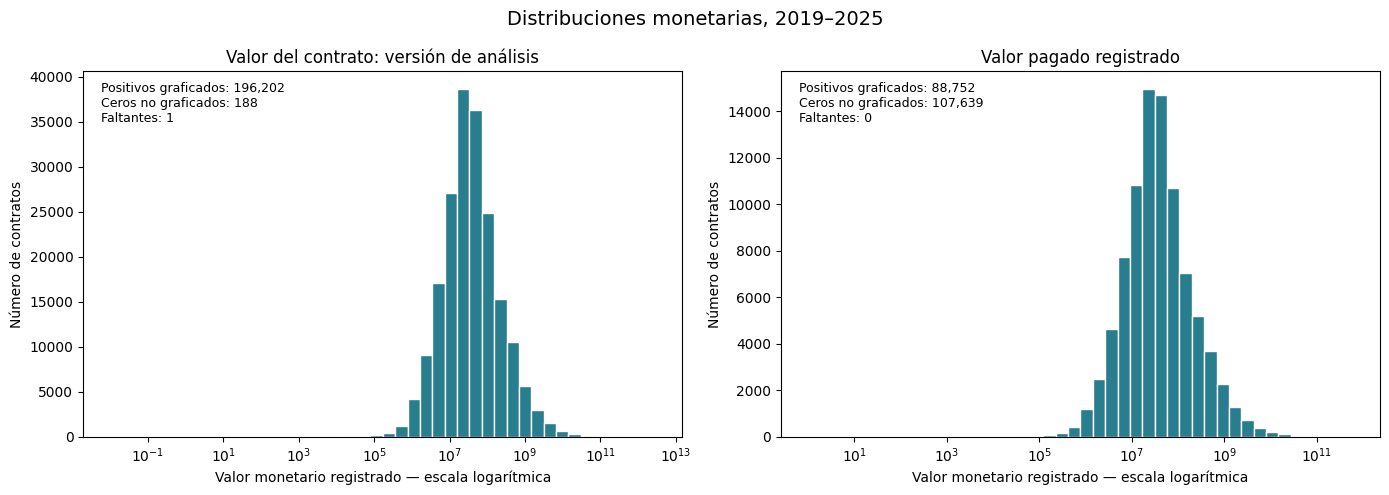

In [61]:
import matplotlib.pyplot as plt
import numpy as np
import textwrap
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))
configuracion = [
    ("valor_contrato_analisis", "Valor del contrato: versión de análisis"),
    ("valor_pagado", "Valor pagado registrado")
]
for eje, (columna, titulo) in zip(ejes, configuracion):
    serie = df[columna]
    positivos = serie[serie > 0]
    limites = np.geomspace(
        positivos.min(), positivos.max(), 45
    )
    eje.hist(
        positivos,
        bins=limites,
        color="#287D8E",
        edgecolor="white"
    )
    eje.set_xscale("log")
    eje.set_title(titulo)
    eje.set_xlabel("Valor monetario registrado — escala logarítmica")
    eje.set_ylabel("Número de contratos")
    eje.text(
        0.03, 0.97,
        f"Positivos graficados: {len(positivos):,}\n"
        f"Ceros no graficados: {int(serie.eq(0).sum()):,}\n"
        f"Faltantes: {int(serie.isna().sum()):,}",
        transform=eje.transAxes,
        va="top",
        fontsize=9,
        bbox=dict(facecolor="white", alpha=0.9, edgecolor="none")
    )
fig.suptitle("Distribuciones monetarias, 2019–2025", fontsize=14)
plt.tight_layout()
plt.show()

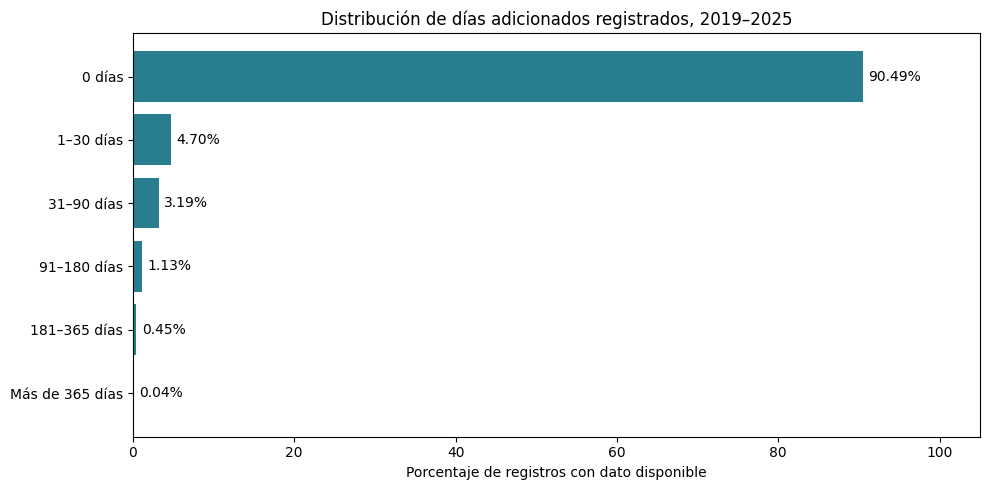

In [62]:
intervalos = [-np.inf, 0, 30, 90, 180, 365, np.inf]
etiquetas = [
    "0 días", "1–30 días", "31–90 días",
    "91–180 días", "181–365 días", "Más de 365 días"
]
grupos_dias = pd.cut(
    df["dias_adicionados"],
    bins=intervalos,
    labels=etiquetas
)
frecuencias_dias = (
    grupos_dias.value_counts(sort=False)
    .reindex(etiquetas, fill_value=0)
)
porcentajes_dias = (
    frecuencias_dias / df["dias_adicionados"].notna().sum() * 100
)
fig, eje = plt.subplots(figsize=(10, 5))
barras = eje.barh(
    etiquetas, porcentajes_dias,
    color="#287D8E"
)
eje.invert_yaxis()
eje.set_xlim(0, 105)
eje.set_xlabel("Porcentaje de registros con dato disponible")
eje.set_title("Distribución de días adicionados registrados, 2019–2025")
eje.bar_label(
    barras,
    labels=[f"{p:.2f}%" for p in porcentajes_dias],
    padding=4
)
plt.tight_layout()
plt.show()

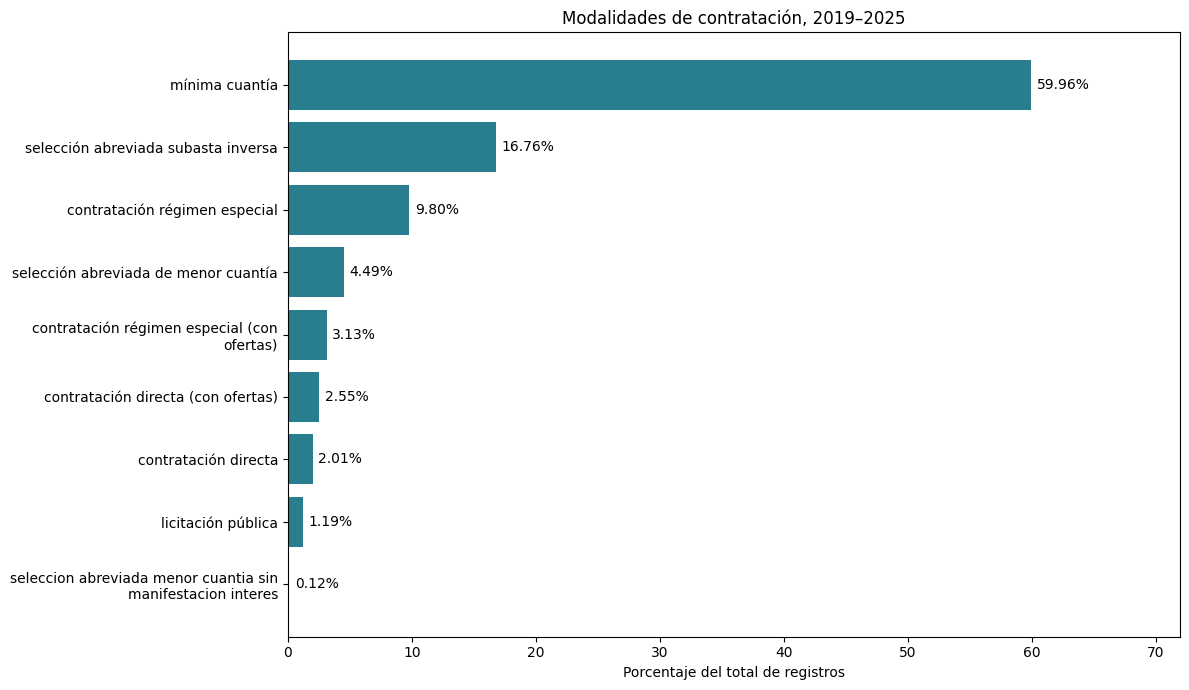

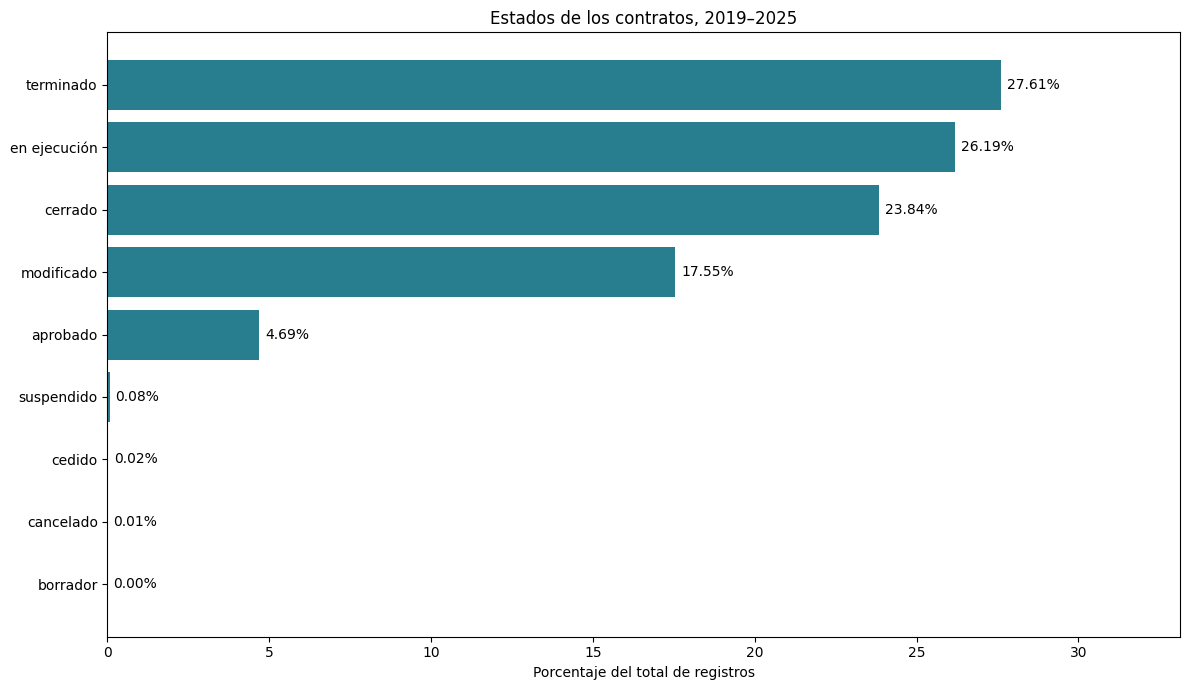

In [63]:
def graficar_categorias(tabla, titulo):
    datos = tabla.sort_values("porcentaje_total", ascending=True)
    etiquetas = [
        textwrap.fill(str(categoria), width=42)
        for categoria in datos.index
    ]
    fig, eje = plt.subplots(figsize=(12, 7))

    barras = eje.barh(
        etiquetas,
        datos["porcentaje_total"],
        color="#287D8E"
    )
    eje.bar_label(
        barras,
        labels=[
            f"{p:.2f}%"
            for p in datos["porcentaje_total"]
        ],
        padding=4
    )
    eje.set_xlim(0, datos["porcentaje_total"].max() * 1.20)
    eje.set_xlabel("Porcentaje del total de registros")
    eje.set_title(titulo)

    plt.tight_layout()
    plt.show()
graficar_categorias(
    tabla_modalidad,
    "Modalidades de contratación, 2019–2025"
)
graficar_categorias(
    tabla_estado,
    "Estados de los contratos, 2019–2025"
)

### 1.7. Reporte breve de entendimiento inicial

  La base contiene 196.391 registros de contratos con fechas de firma
entre 2019 y 2025 y 36 atributos originales: 28 columnas de tipo
object, cinco numéricas y tres de fecha. Las columnas object incluyen
categorías, identificadores, descripciones y enlaces. Se verificaron
196.391 identificadores de contrato distintos, sin identificadores
nulos ni filas completamente duplicadas.

 Se seleccionaron cinco atributos principales: valor del contrato,
valor pagado, días adicionados, modalidad de contratación y estado
del contrato. Estos permiten describir la magnitud económica,
los pagos registrados, las ampliaciones de plazo y el contexto
administrativo necesario para interpretar la ejecución.

 Tras apartar un valor contractual presuntamente erróneo, la media
del valor contractual es de 350,53 millones y la mediana de
33,6 millones. La diferencia evidencia una marcada asimetría
hacia valores altos. La exclusión se aplicó al dato monetario,
sin eliminar el contrato, y se documentó mediante un análisis
de sensibilidad.

 El 54,81 % de los registros presenta valor pagado igual a cero.
Esta condición no se interpreta automáticamente como incumplimiento,
pues requiere considerar el estado contractual y la calidad del
registro. El 9,51 % presenta días adicionados positivos; entre estos
contratos, la mediana de la adición es de 31 días.

 La modalidad predominante es mínima cuantía (59,96 %), seguida de
selección abreviada por subasta inversa (16,76 %). Los estados más
frecuentes son terminado (27,61 %), en ejecución (26,19 %) y cerrado
(23,84 %). Estas distribuciones describen la composición del archivo,
pero no permiten atribuir mayor riesgo a una categoría.

 La revisión identificó información ausente codificada como texto,
inconsistencias temporales y valores monetarios y de plazo que
requieren cautela. Se conservaron las 196.391 filas y la base
original sin modificaciones. Las transformaciones se implementaron
en una copia de trabajo, con indicadores de revisión y versiones
analíticas de las variables afectadas.

 La descripción inicial comprende 2019–2025. La delimitación temporal
y los criterios de elegibilidad para analizar desviaciones se
establecerán en la estrategia de análisis, considerando las
diferencias de estado contractual entre años y la falta de una
fecha de corte confirmada.

### 1.8. Síntesis de calidad de datos y tratamiento

| Hallazgo | Evidencia | Tratamiento aplicado |
|---|---|---|
| Duplicación | No se encontraron filas completas duplicadas ni identificadores repetidos. | No se eliminaron registros por duplicación. |
| Nulos originales | 2.440 fechas de inicio ausentes y cuatro documentos de proveedor ausentes. | Se conservaron sin imputación. |
| Ausencias codificadas como texto | “No definido” aparece en diversos atributos. | Se convirtió en valor faltante en la copia de trabajo, conservando la base original. |
| Categoría “No aplica” | Presente en algunos atributos. | Se conservó diferenciada; su significado requiere interpretación según la variable. |
| Inconsistencias temporales | 13.047 inicios anteriores a la firma, 125 finales anteriores al inicio y 2.601 finales anteriores a la firma. Los grupos pueden solaparse. | Se crearon alertas, sin corregir fechas ni eliminar filas. Su uso en duraciones requiere filtros de consistencia. |
| Finalización en el año 0202 | Un registro identificado. | Se sustituyó por un valor ausente únicamente en fecha_fin_analisis. |
| Valor monetario presuntamente erróneo | Un contrato concentra el 99,467 % de la suma original y presenta una magnitud incompatible con su objeto descrito. | Se apartaron su valor contractual y saldo pendiente en las versiones analíticas, sin imputar cifras ni eliminar la fila. Se compararon los resúmenes con y sin el valor. |
| Adición de plazo excepcional | Un registro presenta 14.276 días adicionados. | Se conservó el dato original y se creó una versión alternativa sin ese valor para el análisis de sensibilidad. |
| Valor contractual cero | 188 registros. | Se conservaron y marcaron. No deben utilizarse como denominador de una proporción pagada. |
| Pago superior al valor contractual | 177 registros. | Se marcaron para revisión, sin corrección automática. |
| Saldo pendiente negativo | 144 registros. | Se marcaron para revisión, sin corrección automática. |
| Pago registrado igual a cero | 107.639 registros. | Se conservó el cero; no se reclasificó automáticamente como faltante o incumplimiento. |
| Diferencias de estados entre años | La composición administrativa cambia según el año de firma. | Se describieron por año; la selección de la población analítica permanece pendiente. |

   Las alertas de calidad no constituyen evidencia de irregularidad
contractual. Apartar el valor monetario inspeccionado tampoco
equivale a validar todos los demás importes. Las decisiones
posteriores deberán precisar las exclusiones por indicador y
sus respectivos denominadores.

## Punto 2. Estrategia de análisis

  Se realizará un análisis observacional y exploratorio orientado a
identificar características asociadas con señales de desviación en
la ejecución contractual. La población principal comprenderá
contratos firmados entre 2021 y 2024 registrados como terminados o
cerrados, para reducir la mezcla de resultados de ejecución con
contratos todavía en curso. Esta delimitación considera la elevada
proporción de contratos aprobados en 2019–2020 y el mayor peso de
contratos en ejecución o modificados en 2025; se evaluará su
sensibilidad al incluir otros años y al analizar cada estado por
separado. Se examinarán las adiciones de plazo registradas y la proporción del
valor contractual pagado. El cierre sin liquidación no se utilizará
como resultado mientras no se verifique que el campo liquidaci_n
describe una liquidación efectivamente realizada, pues la documentación
de SECOP II permite interpretar esta selección como una obligación
aplicable al contrato.

  Se calcularán frecuencias, proporciones, medianas y rangos
intercuartílicos, y se compararán los resultados según modalidad,
destino del gasto, sector y valor contractual. Se formularán
hipótesis explícitas de independencia para variables categóricas
y de igualdad de distribuciones para variables numéricas, utilizando
chi-cuadrado cuando sus frecuencias esperadas sean adecuadas y
pruebas de Mann–Whitney o Kruskal–Wallis según el número de grupos.
Se reportarán tamaños del efecto, resultados significativos y no
significativos, y ajuste de Holm para las familias de contrastes
múltiples. Se examinará la posible dependencia entre contratos de
una misma entidad y se contrastarán los hallazgos principales mediante
remuestreo por entidad. Los gráficos de proporciones, las
distribuciones por grupo y los mapas de calor de modalidad por
destino del gasto permitirán explorar varios atributos conjuntamente,
mostrando los tamaños de los grupos. Las recomendaciones se basarán
en la magnitud de las diferencias, su estabilidad entre años y su
relevancia para la supervisión, sin interpretar las asociaciones
como relaciones causales.

In [64]:
# Normalización de etiquetas para definir la población analítica.
df["estado_analisis"] = (
    df["estado_contrato"]
    .astype("string")
    .str.strip()
    .str.casefold()
)
df["liquidacion_revision"] = (
    df["liquidaci_n"]
    .astype("string")
    .str.strip()
    .str.casefold()
)
df["anio_firma"] = df["fecha_de_firma"].dt.year
print("CATEGORÍAS DEL CAMPO DE LIQUIDACIÓN")
print(
    df["liquidacion_revision"]
    .value_counts(dropna=False)
    .to_string()
)
print("\nESTADO CONTRACTUAL Y LIQUIDACIÓN REGISTRADA")
print(
    pd.crosstab(
        df["estado_analisis"].fillna("sin información"),
        df["liquidacion_revision"].fillna("sin información")
    ).to_string()
)
# Población principal: aún sin exclusiones específicas por indicador.
criterio_periodo = df["anio_firma"].between(2021, 2024)
criterio_estado = df["estado_analisis"].isin(["terminado", "cerrado"])
base_principal = df.loc[
    criterio_periodo & criterio_estado
].copy()
print(f"\nRegistros en la base completa: {len(df):,}")
print(
    "Registros firmados entre 2021 y 2024:",
    f"{int(criterio_periodo.sum()):,}"
)
print(
    "Registros del periodo terminados o cerrados:",
    f"{len(base_principal):,}"
)
print("\nPOBLACIÓN PRINCIPAL POR AÑO Y ESTADO")
print(
    pd.crosstab(
        base_principal["anio_firma"],
        base_principal["estado_analisis"]
    ).to_string()
)

CATEGORÍAS DEL CAMPO DE LIQUIDACIÓN
liquidacion_revision
no    118418
si     77973

ESTADO CONTRACTUAL Y LIQUIDACIÓN REGISTRADA
liquidacion_revision     no     si
estado_analisis                   
aprobado               6898   2313
borrador                  1      0
cancelado                15     11
cedido                   31     12
cerrado               28096  18728
en ejecución          34807  16634
modificado            20699  13763
suspendido               71     82
terminado             27800  26430

Registros en la base completa: 196,391
Registros firmados entre 2021 y 2024: 119,718
Registros del periodo terminados o cerrados: 66,423

POBLACIÓN PRINCIPAL POR AÑO Y ESTADO
estado_analisis  cerrado  terminado
anio_firma                         
2021                7624       6491
2022                8320       8253
2023                7122      10361
2024                6848      11404


## Punto 3. Desarrollo de la estrategia

### 3.1. Población e indicadores

La población principal comprende 66.423 contratos firmados entre
2021 y 2024, registrados como terminados o cerrados. Los resultados
se referirán a esta población y no se generalizarán automáticamente
a todos los contratos de la base.

Se construirán dos indicadores:

- Adición de plazo registrada: presencia de un valor positivo en
  dias_adicionados. Los valores ausentes, negativos o no finitos
  se considerarán no evaluables.
- Proporción pagada registrada: cociente entre valor_pagado y
  valor_contrato_analisis. Se calculará únicamente cuando ambos
  valores sean finitos, el valor contractual sea positivo y el pago
  se encuentre entre cero y el valor contractual.

Los pagos superiores al valor contractual se mantendrán como alertas
separadas y no se recortarán artificialmente al 100 %. Los pagos
iguales a cero se conservarán. La proporción pagada no se interpretará
como ejecución física ni como prueba directa de incumplimiento.

El campo liquidaci_n se conservará para descripción, pero no se
utilizará como evidencia de liquidación realizada o pendiente
sin verificar su definición en la fuente.

In [65]:
# Trabajar sobre una copia de la población principal.
base_principal = base_principal.copy()

# A. Adición de plazo registrada.
dias = base_principal["dias_adicionados"]

plazo_evaluable = (
    dias.notna()
    & np.isfinite(dias)
    & dias.ge(0)
)
base_principal["adicion_plazo"] = (
    dias.gt(0)
    .astype("boolean")
    .where(plazo_evaluable, pd.NA)
)
# B. Proporción pagada registrada.
valor = base_principal["valor_contrato_analisis"]
pago = base_principal["valor_pagado"]
pago_evaluable = (
    valor.notna()
    & pago.notna()
    & np.isfinite(valor)
    & np.isfinite(pago)
    & valor.gt(0)
    & pago.ge(0)
    & pago.le(valor)
)

base_principal["proporcion_pagada"] = np.nan
base_principal.loc[pago_evaluable, "proporcion_pagada"] = (
    pago.loc[pago_evaluable] / valor.loc[pago_evaluable]
)
# Denominadores específicos.
resumen_elegibilidad = pd.DataFrame({
    "indicador": [
        "Adición de plazo",
        "Proporción pagada"
    ],
    "poblacion_inicial": len(base_principal),
    "evaluables": [
        int(plazo_evaluable.sum()),
        int(pago_evaluable.sum())
    ],
    "no_evaluables": [
        int((~plazo_evaluable).sum()),
        int((~pago_evaluable).sum())
    ]
})
print("ELEGIBILIDAD POR INDICADOR")
print(resumen_elegibilidad.to_string(index=False))
adiciones = base_principal["adicion_plazo"].dropna()
proporciones = base_principal["proporcion_pagada"].dropna()
print("\nADICIONES DE PLAZO")
print(f"Contratos con adición: {int(adiciones.sum()):,}")
print(f"Contratos evaluables: {len(adiciones):,}")
print(f"Porcentaje con adición: {100 * adiciones.mean():.2f}%")
print("\nPROPORCIÓN PAGADA — EXPRESADA EN PORCENTAJE")
print(
    proporciones.mul(100)
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90])
    .to_string(float_format=lambda x: f"{x:,.2f}")
)

print(
    "\nContratos evaluables con pago cero:",
    int(proporciones.eq(0).sum())
)

print(
    "Alertas de pago superior al valor contractual original:",
    int(base_principal["alerta_pago_superior_valor"].sum())
)

ELEGIBILIDAD POR INDICADOR
        indicador  poblacion_inicial  evaluables  no_evaluables
 Adición de plazo              66423       66423              0
Proporción pagada              66423       66237            186

ADICIONES DE PLAZO
Contratos con adición: 217
Contratos evaluables: 66,423
Porcentaje con adición: 0.33%

PROPORCIÓN PAGADA — EXPRESADA EN PORCENTAJE
count   66,237.00
mean        57.32
std         48.51
min          0.00
25%          0.00
50%         99.86
75%        100.00
90%        100.00
max        100.00

Contratos evaluables con pago cero: 27029
Alertas de pago superior al valor contractual original: 100


### 3.2. Revisión de la población para el indicador de plazo

   En los contratos terminados o cerrados de 2021–2024, el 0,33 %
registra adiciones de plazo, frente al 9,51 % observado en el
archivo completo. Estas proporciones corresponden a poblaciones
diferentes tanto en periodo como en estado contractual.

   Antes de realizar contrastes, se examina la presencia de adiciones
por estado dentro del mismo periodo. El propósito es determinar
si restringir el análisis a contratos terminados o cerrados
excluye de manera desproporcionada los registros con adiciones.

   La población para el análisis de pagos se mantiene provisionalmente.
La población para las adiciones de plazo se definirá a partir de
esta revisión. En contratos en curso, un valor cero indica ausencia
de adiciones registradas hasta el corte, no ausencia definitiva
de ampliaciones.

In [66]:
base_periodo = df.loc[
    df["anio_firma"].between(2021, 2024)
].copy()
dias_periodo = base_periodo["dias_adicionados"]
plazo_valido_periodo = (
    dias_periodo.notna()
    & np.isfinite(dias_periodo)
    & dias_periodo.ge(0)
)
base_periodo["adicion_plazo"] = (
    dias_periodo.gt(0)
    .astype("boolean")
    .where(plazo_valido_periodo, pd.NA)
)
revision_plazo_estado = (
    base_periodo
    .groupby("estado_analisis", dropna=False)
    .agg(
        contratos=("id_contrato", "size"),
        evaluables=("adicion_plazo", "count"),
        con_adicion=("adicion_plazo", "sum")
    )
)
revision_plazo_estado["porcentaje_con_adicion"] = (
    revision_plazo_estado["con_adicion"]
    / revision_plazo_estado["evaluables"].replace(0, np.nan)
    * 100
)
total_adiciones_periodo = revision_plazo_estado["con_adicion"].sum()

revision_plazo_estado["porcentaje_de_todas_las_adiciones"] = (
    revision_plazo_estado["con_adicion"]
    / (total_adiciones_periodo if total_adiciones_periodo > 0 else np.nan)
    * 100
)
print("ADICIONES POR ESTADO — CONTRATOS FIRMADOS EN 2021–2024")
print(
    revision_plazo_estado.to_string(
        float_format=lambda x: f"{x:,.2f}"
    )
)
indicador_periodo = base_periodo["adicion_plazo"].dropna()
print(
    "\nPorcentaje con adiciones en todos los estados del periodo:",
    f"{100 * indicador_periodo.mean():.2f}%"
)

ADICIONES POR ESTADO — CONTRATOS FIRMADOS EN 2021–2024
                 contratos  evaluables  con_adicion  porcentaje_con_adicion  porcentaje_de_todas_las_adiciones
estado_analisis                                                                                               
aprobado              1709        1709            0                    0.00                               0.00
cancelado               21          21            0                    0.00                               0.00
cedido                  24          24            0                    0.00                               0.00
cerrado              29914       29914           67                    0.22                               0.71
en ejecución         32577       32577            1                    0.00                               0.01
modificado           18898       18898         9267                   49.04                              97.67
suspendido              66          66            3      

In [67]:
resumen_pago_estado = (
    base_principal
    .groupby("estado_analisis")
    .agg(
        contratos=("id_contrato", "size"),
        evaluables=("proporcion_pagada", "count"),
        media_proporcion=("proporcion_pagada", "mean"),
        mediana_proporcion=("proporcion_pagada", "median"),
        pagos_cero=(
            "proporcion_pagada",
            lambda s: int(s.eq(0).sum())
        )
    )
)
resumen_pago_estado["media_porcentaje"] = (
    resumen_pago_estado["media_proporcion"] * 100
)
resumen_pago_estado["mediana_porcentaje"] = (
    resumen_pago_estado["mediana_proporcion"] * 100
)
resumen_pago_estado["porcentaje_pago_cero"] = (
    resumen_pago_estado["pagos_cero"]
    / resumen_pago_estado["evaluables"].replace(0, np.nan)
    * 100
)
print(
    resumen_pago_estado.drop(
        columns=["media_proporcion", "mediana_proporcion"]
    ).to_string(float_format=lambda x: f"{x:,.2f}")
)

                 contratos  evaluables  pagos_cero  media_porcentaje  mediana_porcentaje  porcentaje_pago_cero
estado_analisis                                                                                               
cerrado              29914       29863        9996             64.75              100.00                 33.47
terminado            36509       36374       17033             51.23               78.79                 46.83


### 3.3. Poblaciones definitivas e hipótesis de trabajo

Para las adiciones de plazo se utilizarán los contratos firmados
entre 2021 y 2024 en todos los estados, siempre que el dato sea
evaluable. La restricción a terminados y cerrados reduce la
frecuencia observada de adiciones del 7,93 % al 0,33 %, por lo
que se conservará como análisis de sensibilidad y no como
población principal del indicador de plazo.

Para la proporción pagada se conservarán los contratos terminados
o cerrados con información monetaria evaluable. Los resultados
se examinarán también por separado según estos dos estados.

Se plantean cuatro contrastes globales exploratorios:

1. H0: la presencia de adiciones registradas es independiente de
   la modalidad de contratación. H1: existe asociación.
2. H0: la presencia de adiciones registradas es independiente del
   destino del gasto. H1: existe asociación.
3. H0: la distribución de la proporción pagada es igual entre
   modalidades de contratación. H1: al menos una distribución difiere.
4. H0: la distribución de la proporción pagada es igual entre
   destinos del gasto. H1: al menos una distribución difiere.

Los cuatro contrastes conformarán una familia para el ajuste de
Holm, con nivel de significación de 0,05. Antes de ejecutarlos se
revisarán las categorías, sus tamaños y las frecuencias esperadas.
No se interpretará una diferencia de distribuciones como una
diferencia exclusivamente de medianas.

El sector y el valor contractual se incorporarán en análisis
complementarios claramente identificados como exploratorios.
Los hallazgos principales se revisarán por año y mediante
procedimientos que consideren la agrupación por entidad.

In [68]:
# Bases específicas por indicador.
base_plazo = base_periodo.loc[
    base_periodo["adicion_plazo"].notna()
].copy()
base_pago = base_principal.loc[
    base_principal["proporcion_pagada"].notna()
].copy()
# Normalización de categorías sin modificar las columnas originales.
for base in [base_plazo, base_pago]:
    base["modalidad_analisis"] = (
        base["modalidad_de_contratacion"]
        .astype("string")
        .str.strip()
        .str.casefold()
    )
    base["destino_analisis"] = (
        base["destino_gasto"]
        .astype("string")
        .str.strip()
        .str.casefold()
    )
# Convertir el indicador a entero únicamente tras excluir desconocidos.
base_plazo["adicion_plazo"] = (
    base_plazo["adicion_plazo"].astype(int)
)
for variable in ["modalidad_analisis", "destino_analisis"]:
    print(f"\nADICIONES SEGÚN {variable.upper()}")
    tabla_plazo = (
        base_plazo.groupby(variable, dropna=False)
        .agg(
            evaluables=("adicion_plazo", "size"),
            con_adicion=("adicion_plazo", "sum"),
            proporcion=("adicion_plazo", "mean")
        )
    )
    tabla_plazo["porcentaje_con_adicion"] = (
        tabla_plazo.pop("proporcion") * 100
    )

    print(
        tabla_plazo.to_string(
            float_format=lambda x: f"{x:,.2f}"
        )
    )
    print(f"\nPAGOS SEGÚN {variable.upper()}")
    tabla_pago = (
        base_pago.groupby(variable, dropna=False)
        .agg(
            evaluables=("proporcion_pagada", "size"),
            media=("proporcion_pagada", "mean"),
            mediana=("proporcion_pagada", "median"),
            proporcion_ceros=(
                "proporcion_pagada",
                lambda s: s.eq(0).mean()
            )
        )
    )
    tabla_pago["media_porcentaje"] = tabla_pago.pop("media") * 100
    tabla_pago["mediana_porcentaje"] = tabla_pago.pop("mediana") * 100
    tabla_pago["porcentaje_pago_cero"] = (
        tabla_pago.pop("proporcion_ceros") * 100
    )
    print(
        tabla_pago.to_string(
            float_format=lambda x: f"{x:,.2f}"
        )
    )


ADICIONES SEGÚN MODALIDAD_ANALISIS
                                                             evaluables  con_adicion  porcentaje_con_adicion
modalidad_analisis                                                                                          
contratación directa                                               1966          115                    5.85
contratación directa (con ofertas)                                 3292          247                    7.50
contratación régimen especial                                     12974          620                    4.78
contratación régimen especial (con ofertas)                        4185          650                   15.53
licitación pública                                                 1545          394                   25.50
mínima cuantía                                                    70200         4253                    6.06
seleccion abreviada menor cuantia sin manifestacion interes         181           28        

### 3.4. Contrastes globales

Se evalúa la asociación de las adiciones de plazo con modalidad
y destino del gasto mediante chi-cuadrado de independencia.
Se verifican las frecuencias esperadas y se reporta V de Cramér
como medida de asociación.

La distribución de la proporción pagada se compara entre modalidades
mediante Kruskal–Wallis y entre funcionamiento e inversión mediante
Mann–Whitney bilateral. Se reportan eta cuadrado basado en H y
correlación biserial de rangos, respectivamente. Estas pruebas
evalúan diferencias de distribución y no exclusivamente de medianas.

Los cuatro valores p se ajustan conjuntamente mediante Holm.
Las pruebas convencionales suponen independencia entre observaciones;
dado que una entidad puede tener varios contratos, sus resultados
se consideran preliminares hasta la revisión mediante remuestreo
por entidad. La significación estadística no se equipara con
relevancia práctica ni con causalidad.

In [69]:
from scipy.stats import chi2_contingency, kruskal, mannwhitneyu

# Preparar las cuatro muestras sin modificar las bases anteriores.
destinos_comparables = ["funcionamiento", "inversión"]
plazo_modalidad = base_plazo.dropna(
    subset=["modalidad_analisis", "adicion_plazo"]
).copy()
plazo_destino = base_plazo.loc[
    base_plazo["destino_analisis"].isin(destinos_comparables)
].copy()
pago_modalidad = base_pago.dropna(
    subset=["modalidad_analisis", "proporcion_pagada"]
).copy()
pago_destino = base_pago.loc[
    base_pago["destino_analisis"].isin(destinos_comparables)
].copy()
muestras = [
    ("Plazo × modalidad", len(base_plazo), len(plazo_modalidad)),
    ("Plazo × destino", len(base_plazo), len(plazo_destino)),
    ("Pago × modalidad", len(base_pago), len(pago_modalidad)),
    ("Pago × destino", len(base_pago), len(pago_destino))
]
print("CASOS INCLUIDOS EN CADA CONTRASTE")
for nombre, disponibles, incluidos in muestras:
    print(
        f"{nombre}: {incluidos:,} incluidos; "
        f"{disponibles - incluidos:,} excluidos por categoría."
    )
resultados = []
# 1 y 2. Chi-cuadrado y V de Cramér.
for nombre, datos, variable in [
    ("H1: plazo × modalidad", plazo_modalidad, "modalidad_analisis"),
    ("H2: plazo × destino", plazo_destino, "destino_analisis")
]:
    tabla = pd.crosstab(datos[variable], datos["adicion_plazo"])

    if min(tabla.shape) < 2:
        raise ValueError(f"{nombre}: no hay variación suficiente.")

    chi2, p, gl, esperadas = chi2_contingency(
        tabla, correction=False
    )
    minimo_esperado = esperadas.min()
    porcentaje_menores_5 = (esperadas < 5).mean() * 100
    print(f"\n{name if False else nombre}")
    print(f"Frecuencia esperada mínima: {minimo_esperado:.2f}")
    print(f"Celdas con frecuencia esperada < 5: {porcentaje_menores_5:.2f}%")
    # Criterio conservador: todas las frecuencias esperadas >= 5.
    if minimo_esperado < 5:
        raise ValueError(
            f"{nombre}: revisar frecuencias esperadas antes de "
            "interpretar la aproximación chi-cuadrado."
        )
    n = tabla.to_numpy().sum()
    v_cramer = np.sqrt(
        chi2 / (n * min(tabla.shape[0] - 1, tabla.shape[1] - 1))
    )
    resultados.append({
        "contraste": nombre,
        "prueba": "Chi-cuadrado",
        "n": n,
        "estadistico": chi2,
        "gl": gl,
        "p": p,
        "medida_efecto": "V de Cramér",
        "efecto": v_cramer
    })
# 3. Kruskal–Wallis: proporción pagada entre modalidades.
grupos = [
    grupo["proporcion_pagada"].to_numpy(dtype=float)
    for _, grupo in pago_modalidad.groupby("modalidad_analisis")
]
if len(grupos) < 2 or min(map(len, grupos)) < 5:
    raise ValueError("Revisar tamaños de los grupos para Kruskal–Wallis.")
h, p = kruskal(*grupos)
n = sum(len(grupo) for grupo in grupos)
k = len(grupos)
eta2_h = max(0.0, (h - k + 1) / (n - k))
resultados.append({
    "contraste": "H3: pago × modalidad",
    "prueba": "Kruskal–Wallis",
    "n": n,
    "estadistico": h,
    "gl": k - 1,
    "p": p,
    "medida_efecto": "Eta cuadrado H",
    "efecto": eta2_h
})
# 4. Mann–Whitney: funcionamiento frente a inversión.
x = pago_destino.loc[
    pago_destino["destino_analisis"].eq("funcionamiento"),
    "proporcion_pagada"
].to_numpy(dtype=float)
y = pago_destino.loc[
    pago_destino["destino_analisis"].eq("inversión"),
    "proporcion_pagada"
].to_numpy(dtype=float)

if len(x) == 0 or len(y) == 0:
    raise ValueError("Falta uno de los destinos comparables.")
u, p = mannwhitneyu(
    x, y,
    alternative="two-sided",
    method="asymptotic"
)
# Positivo: valores mayores en funcionamiento.
# Negativo: valores mayores en inversión.
r_biserial = 2 * u / (len(x) * len(y)) - 1
resultados.append({
    "contraste": "H4: pago × destino",
    "prueba": "Mann–Whitney",
    "n": len(x) + len(y),
    "estadistico": u,
    "gl": np.nan,
    "p": p,
    "medida_efecto": "Biserial de rangos",
    "efecto": r_biserial
})
tabla_contrastes = pd.DataFrame(resultados)
# Ajuste de Holm para la familia de cuatro pruebas.
p_originales = tabla_contrastes["p"].to_numpy()
orden = np.argsort(p_originales)
m = len(p_originales)
p_ordenados_ajustados = np.minimum(
    1.0,
    np.maximum.accumulate(
        p_originales[orden] * (m - np.arange(m))
    )
)
p_holm = np.empty(m)
p_holm[orden] = p_ordenados_ajustados
tabla_contrastes["p_holm"] = p_holm
tabla_contrastes["rechaza_H0_005"] = p_holm < 0.05
print("\nRESULTADOS DE LOS CUATRO CONTRASTES")
print(
    tabla_contrastes.to_string(
        index=False,
        formatters={
            "estadistico": "{:.3f}".format,
            "p": "{:.3e}".format,
            "p_holm": "{:.3e}".format,
            "efecto": "{:.4f}".format
        }
    )
)

CASOS INCLUIDOS EN CADA CONTRASTE
Plazo × modalidad: 119,718 incluidos; 0 excluidos por categoría.
Plazo × destino: 119,588 incluidos; 130 excluidos por categoría.
Pago × modalidad: 66,237 incluidos; 0 excluidos por categoría.
Pago × destino: 66,120 incluidos; 117 excluidos por categoría.

H1: plazo × modalidad
Frecuencia esperada mínima: 14.34
Celdas con frecuencia esperada < 5: 0.00%

H2: plazo × destino
Frecuencia esperada mínima: 3833.36
Celdas con frecuencia esperada < 5: 0.00%

RESULTADOS DE LOS CUATRO CONTRASTES
            contraste         prueba      n   estadistico  gl         p      medida_efecto  efecto    p_holm  rechaza_H0_005
H1: plazo × modalidad   Chi-cuadrado 119718      2263.344 8.0 0.000e+00        V de Cramér  0.1375 0.000e+00            True
  H2: plazo × destino   Chi-cuadrado 119588       257.414 1.0 6.282e-58        V de Cramér  0.0464 6.282e-58            True
 H3: pago × modalidad Kruskal–Wallis  66237      2828.068 8.0 0.000e+00     Eta cuadrado H  0.0426 0

### 3.5. Interpretación preliminar y estabilidad

Los cuatro contrastes globales resultaron significativos después
del ajuste de Holm. Sin embargo, la significación no implica que
las diferencias sean grandes ni que las características examinadas
causen las desviaciones.

La asociación entre destino del gasto y adiciones presenta un
V de Cramér de 0,0464. Para modalidad y adiciones, V es de 0,1375.
La comparación de pagos entre modalidades produce un eta cuadrado
basado en H de 0,0426. La correlación biserial de rangos entre
funcionamiento e inversión es de −0,1801, indicando una tendencia
hacia proporciones pagadas mayores en inversión.

Se examina la estabilidad de las diferencias por año y mediante
bootstrap por entidad. Cada réplica selecciona entidades con
reemplazo y conserva conjuntamente sus contratos. Se estiman
diferencias de proporciones de adición y de medias de la proporción
pagada, expresadas como inversión menos funcionamiento.

Los intervalos obtenidos son exploratorios y no sustituyen los
contrastes globales: evalúan diferencias de proporciones y medias,
mientras que Mann–Whitney compara distribuciones. El remuestreo
no corrige problemas de registro, selección ni confusión.

In [70]:
for nombre, datos, resultado in [
    ("ADICIONES", plazo_destino, "adicion_plazo"),
    ("PROPORCIÓN PAGADA", pago_destino, "proporcion_pagada")
]:
    resumen_anual = (
        datos.groupby(["anio_firma", "destino_analisis"])
        .agg(
            n=(resultado, "count"),
            media=(resultado, "mean")
        )
    )
    resumen_anual["porcentaje"] = resumen_anual.pop("media") * 100

    print(f"\n{nombre} POR AÑO Y DESTINO")
    print(
        resumen_anual.to_string(
            float_format=lambda x: f"{x:.2f}"
        )
    )


ADICIONES POR AÑO Y DESTINO
                                 n  porcentaje
anio_firma destino_analisis                   
2021       funcionamiento    13666        6.13
           inversión         10362        9.14
2022       funcionamiento    16633        5.59
           inversión         11416        8.31
2023       funcionamiento    20228        6.99
           inversión         12703        9.20
2024       funcionamiento    20704        8.36
           inversión         13876       10.84

PROPORCIÓN PAGADA POR AÑO Y DESTINO
                                 n  porcentaje
anio_firma destino_analisis                   
2021       funcionamiento     8304       40.48
           inversión          5761       60.66
2022       funcionamiento     9781       49.83
           inversión          6740       65.14
2023       funcionamiento    10595       52.18
           inversión          6766       67.98
2024       funcionamiento    10950       58.80
           inversión          7223       

In [71]:
def bootstrap_destino_por_entidad(
    datos, resultado, replicas=2000, semilla=2026
):
    trabajo = datos[
        ["nombre_entidad", "destino_analisis", resultado]
    ].dropna().copy()
    trabajo["entidad_bootstrap"] = (
        trabajo["nombre_entidad"]
        .astype("string")
        .str.strip()
        .str.casefold()
    )
    # El nombre se usa como identificador operativo de la entidad.
    trabajo = trabajo.loc[
        trabajo["entidad_bootstrap"].ne("")
        & trabajo["destino_analisis"].isin(
            ["funcionamiento", "inversión"]
        )
    ]
    agregados = (
        trabajo.groupby(["entidad_bootstrap", "destino_analisis"])
        [resultado]
        .agg(["sum", "count"])
    )
    destinos = ["funcionamiento", "inversión"]
    sumas = (
        agregados["sum"].unstack(fill_value=0)
        .reindex(columns=destinos, fill_value=0)
        .to_numpy(dtype=float)
    )
    conteos = (
        agregados["count"].unstack(fill_value=0)
        .reindex(columns=destinos, fill_value=0)
        .to_numpy(dtype=float)
    )
    numero_entidades = len(sumas)

    if numero_entidades < 2 or (conteos.sum(axis=0) == 0).any():
        raise ValueError("No hay suficientes entidades o grupos.")
    medias_observadas = sumas.sum(axis=0) / conteos.sum(axis=0)
    diferencia_observada = (
        medias_observadas[1] - medias_observadas[0]
    ) * 100
    rng = np.random.default_rng(semilla)
    diferencias = []
    for _ in range(replicas):
        seleccion = rng.integers(
            0, numero_entidades, size=numero_entidades
        )
        n_replica = conteos[seleccion].sum(axis=0)

        if (n_replica == 0).any():
            continue
        medias_replica = (
            sumas[seleccion].sum(axis=0) / n_replica
        )
        diferencias.append(
            (medias_replica[1] - medias_replica[0]) * 100
        )
    inferior, superior = np.quantile(
        diferencias, [0.025, 0.975]
    )
    return {
        "resultado": resultado,
        "contratos_incluidos": len(trabajo),
        "entidades": numero_entidades,
        "replicas_validas": len(diferencias),
        "diferencia_pp": diferencia_observada,
        "IC95_inferior_pp": inferior,
        "IC95_superior_pp": superior
    }
resultados_bootstrap = pd.DataFrame([
    bootstrap_destino_por_entidad(
        plazo_destino, "adicion_plazo"
    ),
    bootstrap_destino_por_entidad(
        pago_destino, "proporcion_pagada"
    )
])
print("DIFERENCIAS: INVERSIÓN MENOS FUNCIONAMIENTO")
print(
    resultados_bootstrap.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}"
    )
)

DIFERENCIAS: INVERSIÓN MENOS FUNCIONAMIENTO
        resultado  contratos_incluidos  entidades  replicas_validas  diferencia_pp  IC95_inferior_pp  IC95_superior_pp
    adicion_plazo               119588       2879              2000          2.554             1.344             3.732
proporcion_pagada                66120       2116              2000         15.869            10.065            21.879


### 3.6. Estabilidad de las diferencias por destino del gasto

  El bootstrap por entidad (2.000 réplicas, remuestreando entidades
completas) confirma las dos diferencias observadas. En adiciones de
plazo, los contratos de inversión superan a los de funcionamiento en
2,55 puntos porcentuales (IC 95 %: 1,34 a 3,73), es decir, alrededor
de un 37 % más en términos relativos frente al 6,89 % de funcionamiento.
En proporción pagada, inversión supera a funcionamiento en 15,87 puntos
(IC 95 %: 10,07 a 21,88). Ningún intervalo incluye el cero, por lo que
las diferencias no se explican solo por la concentración de contratos
en pocas entidades. La dirección se mantiene en cada año de 2021 a 2024.

  Los dos indicadores señalan riesgos distintos. Inversión concentra más
ampliaciones de plazo, mientras que funcionamiento concentra más
contratos terminados o cerrados sin pagos registrados (47,0 % frente
a 31,5 %). Para la supervisión, el destino del gasto indica qué tipo
de desviación vigilar más que si hay que vigilar o no. La diferencia en
adiciones es estadísticamente robusta, pero de magnitud moderada
(V de Cramér = 0,046).

In [72]:
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu
def ajuste_holm(p_valores):
    p_valores = np.asarray(p_valores, dtype=float)
    orden = np.argsort(p_valores)
    m = len(p_valores)
    ajustados = np.minimum(
        1.0,
        np.maximum.accumulate(p_valores[orden] * (m - np.arange(m)))
    )
    salida = np.empty(m)
    salida[orden] = ajustados
    return salida
# Referencia: la modalidad más frecuente.
referencia = "mínima cuantía"
# A. Adiciones de plazo: cada modalidad frente a mínima cuantía.
ref_plazo = plazo_modalidad.loc[
    plazo_modalidad["modalidad_analisis"].eq(referencia), "adicion_plazo"
]
filas_plazo = []
for modalidad, grupo in plazo_modalidad.groupby("modalidad_analisis"):
    if modalidad == referencia:
        continue
    g = grupo["adicion_plazo"]
    tabla = np.array([
        [g.sum(), len(g) - g.sum()],
        [ref_plazo.sum(), len(ref_plazo) - ref_plazo.sum()]
    ])
    _, _, _, esperadas = chi2_contingency(tabla, correction=False)
    # Fisher cuando alguna frecuencia esperada es menor que 5.
    if esperadas.min() < 5:
        _, p = fisher_exact(tabla)
        prueba = "Fisher"
    else:
        _, p, _, _ = chi2_contingency(tabla, correction=False)
        prueba = "Chi-cuadrado"
    filas_plazo.append({
        "modalidad": modalidad,
        "n": len(g),
        "porcentaje_adicion": g.mean() * 100,
        "diferencia_pp": (g.mean() - ref_plazo.mean()) * 100,
        "razon_riesgo": g.mean() / ref_plazo.mean(),
        "prueba": prueba,
        "p": p
    })
pares_plazo = pd.DataFrame(filas_plazo)
pares_plazo["p_holm"] = ajuste_holm(pares_plazo["p"])
pares_plazo["significativo_005"] = pares_plazo["p_holm"] < 0.05
pares_plazo = pares_plazo.sort_values("diferencia_pp", ascending=False)
# B. Proporción pagada: cada modalidad frente a mínima cuantía.
ref_pago = pago_modalidad.loc[
    pago_modalidad["modalidad_analisis"].eq(referencia),
    "proporcion_pagada"
].to_numpy(dtype=float)
filas_pago = []
for modalidad, grupo in pago_modalidad.groupby("modalidad_analisis"):
    if modalidad == referencia:
        continue
    g = grupo["proporcion_pagada"].to_numpy(dtype=float)
    u, p = mannwhitneyu(g, ref_pago, alternative="two-sided",
                        method="asymptotic")
    filas_pago.append({
        "modalidad": modalidad,
        "n": len(g),
        "mediana_pct": np.median(g) * 100,
        "pago_cero_pct": (g == 0).mean() * 100,
        "dif_pago_cero_pp": ((g == 0).mean() - (ref_pago == 0).mean()) * 100,
        # Positivo: proporciones mayores en la modalidad que en la referencia.
        "biserial_rangos": 2 * u / (len(g) * len(ref_pago)) - 1,
        "p": p
    })
pares_pago = pd.DataFrame(filas_pago)
pares_pago["p_holm"] = ajuste_holm(pares_pago["p"])
pares_pago["significativo_005"] = pares_pago["p_holm"] < 0.05
pares_pago = pares_pago.sort_values("biserial_rangos")
print(f"REFERENCIA: {referencia}")
print(f"Adiciones en la referencia: {ref_plazo.mean() * 100:.2f}% "
      f"(n = {len(ref_plazo):,})")
print(f"Pago cero en la referencia: {(ref_pago == 0).mean() * 100:.2f}% "
      f"(n = {len(ref_pago):,})")
print("\nADICIONES DE PLAZO — CADA MODALIDAD FRENTE A LA REFERENCIA")
print(pares_plazo.to_string(index=False, formatters={
    "porcentaje_adicion": "{:.2f}".format,
    "diferencia_pp": "{:+.2f}".format,
    "razon_riesgo": "{:.2f}".format,
    "p": "{:.2e}".format, "p_holm": "{:.2e}".format}))
print("\nPROPORCIÓN PAGADA — CADA MODALIDAD FRENTE A LA REFERENCIA")
print(pares_pago.to_string(index=False, formatters={
    "mediana_pct": "{:.2f}".format,
    "pago_cero_pct": "{:.2f}".format,
    "dif_pago_cero_pp": "{:+.2f}".format,
    "biserial_rangos": "{:+.3f}".format,
    "p": "{:.2e}".format, "p_holm": "{:.2e}".format}))

REFERENCIA: mínima cuantía
Adiciones en la referencia: 6.06% (n = 70,200)
Pago cero en la referencia: 36.67% (n = 39,248)

ADICIONES DE PLAZO — CADA MODALIDAD FRENTE A LA REFERENCIA
                                                  modalidad     n porcentaje_adicion diferencia_pp razon_riesgo       prueba         p    p_holm  significativo_005
                                         licitación pública  1545              25.50        +19.44         4.21 Chi-cuadrado 3.55e-207 2.84e-206               True
                contratación régimen especial (con ofertas)  4185              15.53         +9.47         2.56 Chi-cuadrado 3.26e-127 1.96e-126               True
seleccion abreviada menor cuantia sin manifestacion interes   181              15.47         +9.41         2.55 Chi-cuadrado  1.22e-07  3.66e-07               True
                       selección abreviada de menor cuantía  5235              12.74         +6.68         2.10 Chi-cuadrado  1.36e-79  6.81e-79               Tru

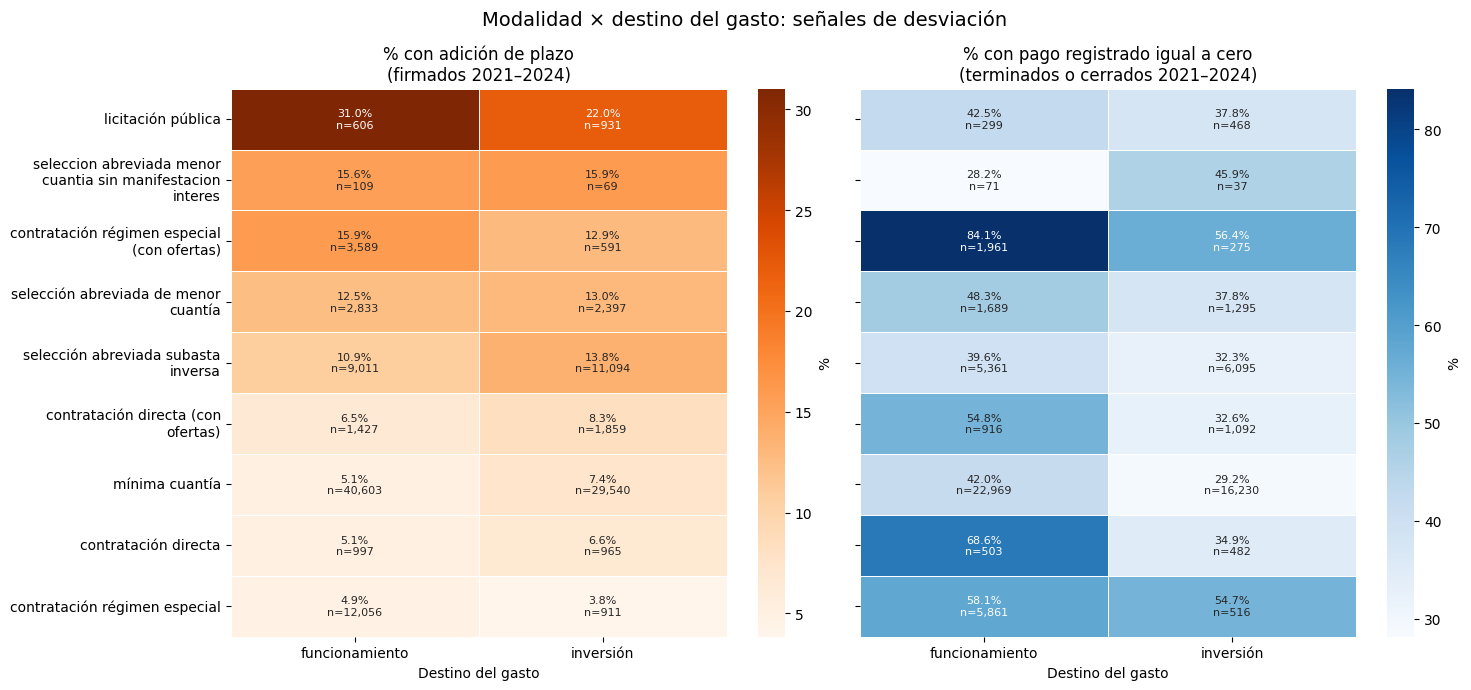

In [73]:
import textwrap
minimo_celda = 30
def matriz_calor(datos, fila, columna, valor, funcion):
    tabla = datos.pivot_table(index=fila, columns=columna, values=valor,
                              aggfunc=funcion)
    conteos = datos.pivot_table(index=fila, columns=columna, values=valor,
                                aggfunc="size")
    return tabla, conteos.reindex_like(tabla)
adicion_md, n_adicion_md = matriz_calor(
    plazo_destino, "modalidad_analisis", "destino_analisis",
    "adicion_plazo", "mean")
pago_cero_md, n_pago_md = matriz_calor(
    pago_destino.assign(pago_cero=pago_destino["proporcion_pagada"].eq(0)),
    "modalidad_analisis", "destino_analisis", "pago_cero", "mean")
fig, ejes = plt.subplots(1, 2, figsize=(15, 7), sharey=True)
paneles = [
    (adicion_md, n_adicion_md,
     "% con adición de plazo\n(firmados 2021–2024)", "Oranges"),
    (pago_cero_md, n_pago_md,
     "% con pago registrado igual a cero\n(terminados o cerrados 2021–2024)", "Blues")
]
orden_filas = adicion_md.mean(axis=1).sort_values(ascending=False).index
for eje, (tabla, conteos, titulo, mapa) in zip(ejes, paneles):
    tabla = tabla.reindex(orden_filas) * 100
    conteos = conteos.reindex(orden_filas)
    visible = tabla.mask(conteos.fillna(0) < minimo_celda)
    anotaciones = (visible.round(1).astype(str) + "%\nn="
                   + conteos.fillna(0).astype(int).map("{:,}".format))
    anotaciones = anotaciones.where(visible.notna(), "n<30")
    sns.heatmap(visible, annot=anotaciones, fmt="", cmap=mapa,
                cbar_kws={"label": "%"}, linewidths=0.5, ax=eje,
                annot_kws={"fontsize": 8})
    eje.set_title(titulo)
    eje.set_xlabel("Destino del gasto")
    eje.set_ylabel("")
ejes[0].set_yticklabels([textwrap.fill(t, 32) for t in orden_filas], rotation=0)
fig.suptitle("Modalidad × destino del gasto: señales de desviación", fontsize=14)
plt.tight_layout()
plt.show()

### 3.7. Qué modalidades explican las asociaciones

  **Adiciones de plazo.** Frente a mínima cuantía (6,06 %), licitación
pública presenta la mayor frecuencia de adiciones: 25,50 %, 4,2 veces
la de la referencia (+19,4 pp). Le siguen régimen especial con ofertas
(15,53 %; razón 2,56), selección abreviada de menor cuantía (12,74 %;
2,10) y subasta inversa (12,48 %; 2,06). Contratación directa con ofertas
difiere de forma significativa, pero con una magnitud pequeña (+1,44 pp).
**Contratación directa no difiere de la referencia** (5,85 %;
p ajustado = 0,70), por lo que no se rechaza H0 para este par.
Régimen especial sin ofertas registra menos adiciones (4,78 %; razón 0,79).
Selección abreviada sin manifestación de interés alcanza 15,47 %, pero
con solo 181 contratos.

  **Pagos registrados.** El patrón se invierte. Régimen especial con
ofertas concentra la mayor proporción de contratos terminados o cerrados
sin pago registrado (80,76 %; +44,1 pp frente a mínima cuantía; biserial
= −0,48, efecto grande). Le siguen régimen especial (57,75 %; −0,26) y
contratación directa (51,92 %; −0,14). En subasta inversa y en
contratación directa con ofertas la diferencia es significativa, pero
de magnitud despreciable (|r| < 0,07), un efecto del tamaño de la
muestra. **Selección abreviada sin manifestación de interés no difiere
de la referencia** (p ajustado = 0,42).

  **Dos perfiles de riesgo.** Las modalidades competitivas y de mayor
cuantía (licitación, selección abreviada, subasta) se asocian con
**ampliaciones de plazo**. Las modalidades sin concurrencia plural
(régimen especial, contratación directa) se asocian con **contratos
cerrados sin pagos registrados**. Régimen especial con ofertas aparece
alto en ambos indicadores.

  **Interacción con el destino del gasto.** El mapa de calor muestra que
la mayor frecuencia de adiciones en inversión no es uniforme. En
licitación pública (31,0 % frente a 22,0 %) y en régimen especial con
ofertas (15,9 % frente a 12,9 %) el patrón se invierte y funcionamiento
supera a inversión. En pagos, funcionamiento presenta más pago cero en
casi todas las modalidades. Las combinaciones más críticas son régimen
especial con ofertas en funcionamiento (84,1 %) y contratación directa
en funcionamiento (68,6 %, frente a 34,9 % en inversión).

  **Cautelas.** (1) La modalidad está ligada al valor del contrato por
norma: la licitación se usa para cuantías altas y la mínima cuantía para
las bajas. Parte de estas diferencias puede deberse al valor, lo que se
examina a continuación. (2) El pago cero en régimen especial puede
reflejar que esas entidades registran sus pagos fuera de SECOP II, y no
necesariamente presupuesto no ejecutado. Debe tratarse como una alerta
de registro que conviene verificar.

LÍMITES DE LOS QUINTILES (millones de pesos)
Q1: 0.0 a 9.8
Q2: 9.8 a 24.1
Q3: 24.1 a 48.7
Q4: 48.7 a 139.9
Q5: 139.9 a 2,115,000.0

INDICADORES POR QUINTIL DE VALOR
               n_plazo  pct_adicion  n_pago  mediana_pagada_pct  pct_pago_cero
quintil_valor                                                                 
Q1               23944         2.79   12875               99.99          42.82
Q2               23944         5.35   13159               99.99          39.40
Q3               23942         6.79   13365               99.97          38.95
Q4               23943         9.46   13517               99.76          40.70
Q5               23944        15.24   13321               93.90          42.23

CONTRASTES DE TENDENCIA SEGÚN VALOR
                     contraste           prueba estadistico        p efecto medida_efecto   p_holm
H5: adición × quintil de valor Cochran–Armitage      52.541 0.00e+00  5.454   Razón Q5/Q1 0.00e+00
 H6: proporción pagada × valor         Spearman

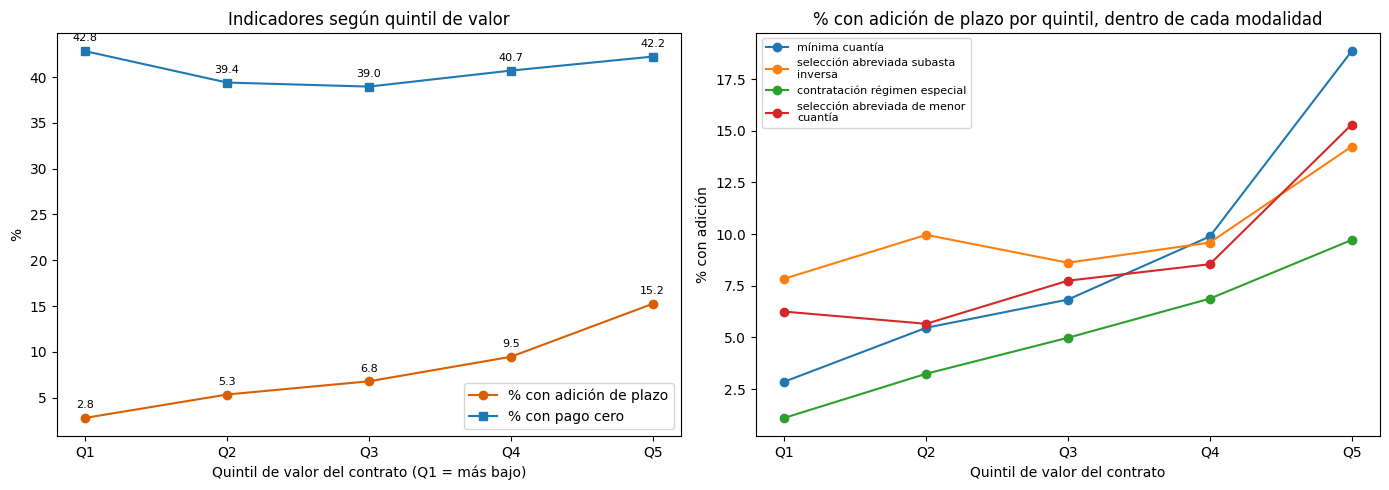

In [74]:
from scipy.stats import chi2, kruskal, spearmanr
def tendencia_cochran_armitage(exitos, totales):
    # Prueba de tendencia lineal para proporciones en grupos ordenados.
    exitos = np.asarray(exitos, float)
    totales = np.asarray(totales, float)
    puntajes = np.arange(len(totales), dtype=float)
    p_global = exitos.sum() / totales.sum()
    t = np.sum(puntajes * (exitos - totales * p_global))
    var = p_global * (1 - p_global) * (
        np.sum(totales * puntajes**2)
        - np.sum(totales * puntajes)**2 / totales.sum()
    )
    z = t / np.sqrt(var)
    return z, chi2.sf(z**2, 1)
# Quintiles definidos una sola vez sobre la base de plazo (2021–2024)
# y aplicados a ambas bases para que los rangos sean idénticos.
valores_ref = base_plazo["valor_contrato_analisis"].dropna()
_, cortes = pd.qcut(valores_ref, 5, retbins=True, duplicates="drop")
cortes[0], cortes[-1] = -np.inf, np.inf
etiquetas_q = [f"Q{i}" for i in range(1, len(cortes))]
for base in [base_plazo, base_pago]:
    base["quintil_valor"] = pd.cut(
        base["valor_contrato_analisis"], bins=cortes, labels=etiquetas_q
    )
print("LÍMITES DE LOS QUINTILES (millones de pesos)")
limites = pd.qcut(valores_ref, 5, duplicates="drop").cat.categories
for etiqueta, intervalo in zip(etiquetas_q, limites):
    print(f"{etiqueta}: {max(intervalo.left, 0)/1e6:,.1f} "
          f"a {intervalo.right/1e6:,.1f}")
# A. Adiciones y pagos por quintil.
plazo_q = (base_plazo.dropna(subset=["quintil_valor"])
           .groupby("quintil_valor", observed=True)["adicion_plazo"]
           .agg(n="size", con_adicion="sum", proporcion="mean"))
pago_q = (base_pago.dropna(subset=["quintil_valor"])
          .groupby("quintil_valor", observed=True)["proporcion_pagada"]
          .agg(n="size", mediana="median",
               pago_cero=lambda s: s.eq(0).mean()))
tabla_q = pd.DataFrame({
    "n_plazo": plazo_q["n"],
    "pct_adicion": plazo_q["proporcion"] * 100,
    "n_pago": pago_q["n"],
    "mediana_pagada_pct": pago_q["mediana"] * 100,
    "pct_pago_cero": pago_q["pago_cero"] * 100
})
print("\nINDICADORES POR QUINTIL DE VALOR")
print(tabla_q.to_string(float_format=lambda x: f"{x:,.2f}"))
# B. Contrastes de tendencia.
# H5: la proporción de adiciones no cambia con el quintil de valor.
z, p_h5 = tendencia_cochran_armitage(plazo_q["con_adicion"], plazo_q["n"])
# H6: la proporción pagada no se asocia monótonamente con el valor.
datos_h6 = base_pago.dropna(subset=["valor_contrato_analisis",
                                    "proporcion_pagada"])
rho, p_h6 = spearmanr(datos_h6["valor_contrato_analisis"],
                      datos_h6["proporcion_pagada"])
grupos_q = [g["proporcion_pagada"].to_numpy(float)
            for _, g in base_pago.dropna(subset=["quintil_valor"])
            .groupby("quintil_valor", observed=True)]
h_q, p_kw_q = kruskal(*grupos_q)
contrastes_valor = pd.DataFrame([
    {"contraste": "H5: adición × quintil de valor",
     "prueba": "Cochran–Armitage", "estadistico": z, "p": p_h5,
     "efecto": plazo_q["proporcion"].iloc[-1] / plazo_q["proporcion"].iloc[0],
     "medida_efecto": "Razón Q5/Q1"},
    {"contraste": "H6: proporción pagada × valor",
     "prueba": "Spearman", "estadistico": rho, "p": p_h6,
     "efecto": rho, "medida_efecto": "rho"},
])
contrastes_valor["p_holm"] = ajuste_holm(contrastes_valor["p"])
print("\nCONTRASTES DE TENDENCIA SEGÚN VALOR")
print(contrastes_valor.to_string(index=False, formatters={
    "estadistico": "{:.3f}".format, "p": "{:.2e}".format,
    "p_holm": "{:.2e}".format, "efecto": "{:.3f}".format}))
print(f"(Complemento: Kruskal–Wallis entre quintiles, "
      f"H = {h_q:,.1f}, p = {p_kw_q:.2e})")
# C. Control por modalidad: ¿el efecto del valor persiste dentro de
# cada modalidad? Si desaparece, el valor solo reflejaba la modalidad.
modalidades_grandes = (base_plazo["modalidad_analisis"]
                       .value_counts().head(4).index)
estratos = []
for modalidad in modalidades_grandes:
    sub = base_plazo.loc[base_plazo["modalidad_analisis"].eq(modalidad)]
    sub = sub.dropna(subset=["quintil_valor"])
    agg = (sub.groupby("quintil_valor", observed=True)["adicion_plazo"]
           .agg(["sum", "size", "mean"]))
    agg = agg.loc[agg["size"] >= 30]
    if len(agg) < 2:
        continue
    z_m, p_m = tendencia_cochran_armitage(agg["sum"], agg["size"])
    fila = {"modalidad": modalidad, "n": int(agg["size"].sum()),
            "z_tendencia": z_m, "p": p_m}
    fila.update({q: v * 100 for q, v in agg["mean"].items()})
    estratos.append(fila)
estratos = pd.DataFrame(estratos)
estratos["p_holm"] = ajuste_holm(estratos["p"])
print("\n% CON ADICIÓN POR QUINTIL, DENTRO DE CADA MODALIDAD (celdas n ≥ 30)")
print(estratos.to_string(index=False, float_format=lambda x: f"{x:,.2f}",
      formatters={"p": "{:.2e}".format, "p_holm": "{:.2e}".format}))
# D. Gráfico: indicadores por quintil, global y por modalidad.
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))
x = tabla_q.index.astype(str)
ejes[0].plot(x, tabla_q["pct_adicion"], marker="o", color="#D95F02",
             label="% con adición de plazo")
ejes[0].plot(x, tabla_q["pct_pago_cero"], marker="s", color="#1F78B4",
             label="% con pago cero")
for q, fila in tabla_q.iterrows():
    for col in ["pct_adicion", "pct_pago_cero"]:
        ejes[0].annotate(f"{fila[col]:.1f}", (str(q), fila[col]),
                         textcoords="offset points", xytext=(0, 7),
                         ha="center", fontsize=8)
ejes[0].set_title("Indicadores según quintil de valor")
ejes[0].set_xlabel("Quintil de valor del contrato (Q1 = más bajo)")
ejes[0].set_ylabel("%")
ejes[0].legend()
for _, fila in estratos.iterrows():
    serie = fila[[q for q in etiquetas_q if q in fila.index]].astype(float)
    ejes[1].plot(serie.index, serie.values, marker="o",
                 label=textwrap.fill(fila["modalidad"], 30))
ejes[1].set_title("% con adición de plazo por quintil, dentro de cada modalidad")
ejes[1].set_xlabel("Quintil de valor del contrato")
ejes[1].set_ylabel("% con adición")
ejes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

### 3.8. Valor del contrato

  **H5 (adiciones × valor): se rechaza H0.** La frecuencia de adiciones
crece de forma monótona con el valor: 2,79 % en el quintil más bajo
(hasta 9,8 millones) y 15,24 % en el más alto (más de 139,9 millones),
es decir, 5,5 veces más (Cochran–Armitage z = 52,5; p ajustado < 0,001).
La tendencia se mantiene **dentro de cada una de las cuatro modalidades
más frecuentes** (todas con p ajustado < 10⁻¹⁰). En mínima cuantía pasa
de 2,86 % a 18,85 % y en régimen especial de 1,11 % a 9,72 %. Por lo
tanto, el valor no se limita a reflejar la modalidad: es un factor
asociado por sí mismo. Es el criterio de focalización más fuerte y
consistente del análisis.

  **H6 (proporción pagada × valor): se rechaza H0, pero sin relevancia
práctica.** La correlación de Spearman es significativa por el tamaño
de la muestra, pero despreciable (ρ = −0,071). El porcentaje de pago
cero se mantiene entre 39 % y 43 % en todos los quintiles, con una
ligera forma de U. La mediana pagada solo baja en el quintil superior
(93,9 % frente a cerca de 100 %). El valor no sirve para anticipar
contratos cerrados sin pagos registrados; para ese riesgo, la modalidad
y el destino son más informativos.

  **Cautela.** El quintil superior incluye valores de hasta 2,1 billones
de pesos. Aunque la tendencia se observa en todos los quintiles y no
depende de casos extremos, esos importes deben verificarse, igual que
el caso apartado en el punto 1.

MÍNIMA CUANTÍA POR ENCIMA DE 100 SMMLV DEL AÑO DE FIRMA
Contratos: 911 de 70,200 (1.30%)
                 n  pct_adicion
supera_tope                    
False        69289         5.94
True           911        15.04

Valores más altos registrados en mínima cuantía (millones):
149008    2115000.0
136637      87750.0
7399        81995.1
15995       75900.0
113310      64974.0

Los 10 sectores más frecuentes cubren 91.4% de la base de plazo.

INDICADORES POR SECTOR (10 más frecuentes)
                                  n_plazo  pct_adicion  n_pago  pct_pago_cero  mediana_valor_mill
sector_analisis                                                                                  
trabajo                              9152        13.66    5231           9.21               33.77
defensa                             18919         8.40   13456          44.69               59.61
salud y protección social           14566         8.22    7993          69.89               38.88
servicio público      

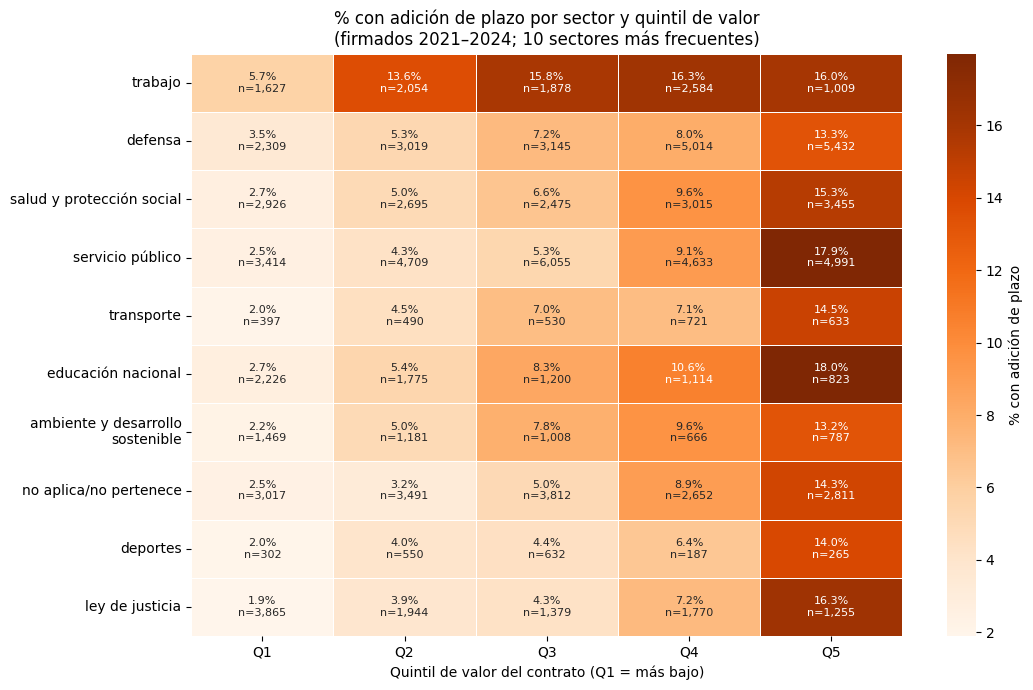

In [75]:
# A. Verificación: mínima cuantía por encima del tope legal.
# Tope de mínima cuantía: 100 SMMLV (10 % de la menor cuantía máxima).
smmlv = {2021: 908_526, 2022: 1_000_000, 2023: 1_160_000, 2024: 1_300_000}
mc = base_plazo.loc[
    base_plazo["modalidad_analisis"].eq("mínima cuantía")
].copy()
mc["tope_minima_cuantia"] = mc["anio_firma"].map(smmlv) * 100
mc["supera_tope"] = mc["valor_contrato_analisis"] > mc["tope_minima_cuantia"]
print("MÍNIMA CUANTÍA POR ENCIMA DE 100 SMMLV DEL AÑO DE FIRMA")
print(f"Contratos: {int(mc['supera_tope'].sum()):,} de {len(mc):,} "
      f"({mc['supera_tope'].mean() * 100:.2f}%)")
print(mc.groupby("supera_tope")["adicion_plazo"]
      .agg(n="size", pct_adicion="mean")
      .assign(pct_adicion=lambda t: t["pct_adicion"] * 100)
      .to_string(float_format=lambda x: f"{x:,.2f}"))
print("\nValores más altos registrados en mínima cuantía (millones):")
print((mc["valor_contrato_analisis"].nlargest(5) / 1e6).round(1).to_string())
# B. Sector: normalización y contrastes globales.
for base in [base_plazo, base_pago]:
    base["sector_analisis"] = (base["sector"].astype("string")
                               .str.strip().str.casefold())
top_sectores = base_plazo["sector_analisis"].value_counts().head(10).index
plazo_sector = base_plazo.loc[base_plazo["sector_analisis"].isin(top_sectores)]
pago_sector = base_pago.loc[base_pago["sector_analisis"].isin(top_sectores)]
print(f"\nLos 10 sectores más frecuentes cubren "
      f"{len(plazo_sector) / len(base_plazo) * 100:.1f}% de la base de plazo.")

tabla_sector = pd.DataFrame({
    "n_plazo": plazo_sector.groupby("sector_analisis").size(),
    "pct_adicion": plazo_sector.groupby("sector_analisis")
                   ["adicion_plazo"].mean() * 100,
    "n_pago": pago_sector.groupby("sector_analisis").size(),
    "pct_pago_cero": pago_sector.groupby("sector_analisis")
                     ["proporcion_pagada"].apply(lambda s: s.eq(0).mean()) * 100,
    "mediana_valor_mill": plazo_sector.groupby("sector_analisis")
                          ["valor_contrato_analisis"].median() / 1e6
}).sort_values("pct_adicion", ascending=False)
print("\nINDICADORES POR SECTOR (10 más frecuentes)")
print(tabla_sector.to_string(float_format=lambda x: f"{x:,.2f}"))
# H7: adiciones independientes del sector.
# H8: distribución de la proporción pagada igual entre sectores.
tabla_h7 = pd.crosstab(plazo_sector["sector_analisis"],
                       plazo_sector["adicion_plazo"])
chi2_h7, p_h7, gl_h7, esp_h7 = chi2_contingency(tabla_h7, correction=False)
v_h7 = np.sqrt(chi2_h7 / (tabla_h7.to_numpy().sum() * (min(tabla_h7.shape) - 1)))
grupos_h8 = [g["proporcion_pagada"].to_numpy(float)
             for _, g in pago_sector.groupby("sector_analisis")]
h_h8, p_h8 = kruskal(*grupos_h8)
n_h8, k_h8 = sum(map(len, grupos_h8)), len(grupos_h8)
contrastes_sector = pd.DataFrame([
    {"contraste": "H7: adición × sector", "prueba": "Chi-cuadrado",
     "estadistico": chi2_h7, "gl": gl_h7, "p": p_h7,
     "medida_efecto": "V de Cramér", "efecto": v_h7,
     "esperada_min": esp_h7.min()},
    {"contraste": "H8: pago × sector", "prueba": "Kruskal–Wallis",
     "estadistico": h_h8, "gl": k_h8 - 1, "p": p_h8,
     "medida_efecto": "Eta cuadrado H",
     "efecto": max(0.0, (h_h8 - k_h8 + 1) / (n_h8 - k_h8)),
     "esperada_min": np.nan},
])
contrastes_sector["p_holm"] = ajuste_holm(contrastes_sector["p"])
print("\nCONTRASTES POR SECTOR")
print(contrastes_sector.to_string(index=False, formatters={
    "estadistico": "{:.2f}".format, "p": "{:.2e}".format,
    "p_holm": "{:.2e}".format, "efecto": "{:.4f}".format,
    "esperada_min": "{:.1f}".format}))
# C. Mapa de calor sector × quintil de valor: ¿el sector añade
# información una vez se tiene en cuenta el valor?
calor_sq = plazo_sector.pivot_table(
    index="sector_analisis", columns="quintil_valor",
    values="adicion_plazo", aggfunc="mean", observed=True) * 100
n_sq = plazo_sector.pivot_table(
    index="sector_analisis", columns="quintil_valor",
    values="adicion_plazo", aggfunc="size", observed=True
).reindex_like(calor_sq)
calor_sq = calor_sq.reindex(tabla_sector.index)
n_sq = n_sq.reindex(tabla_sector.index)
visible = calor_sq.mask(n_sq.fillna(0) < 30)
anot = (visible.round(1).astype(str) + "%\nn="
        + n_sq.fillna(0).astype(int).map("{:,}".format)
        ).where(visible.notna(), "n<30")
fig, eje = plt.subplots(figsize=(11, 7))
sns.heatmap(visible, annot=anot, fmt="", cmap="Oranges", linewidths=0.5,
            cbar_kws={"label": "% con adición de plazo"}, ax=eje,
            annot_kws={"fontsize": 8})
eje.set_yticklabels([textwrap.fill(t, 30) for t in visible.index], rotation=0)
eje.set_xlabel("Quintil de valor del contrato (Q1 = más bajo)")
eje.set_ylabel("")
eje.set_title("% con adición de plazo por sector y quintil de valor\n"
              "(firmados 2021–2024; 10 sectores más frecuentes)")
plt.tight_layout()
plt.show()

### 3.9. Hallazgo de calidad: mínima cuantía por encima del tope legal

  El tope de la mínima cuantía es de 100 SMMLV. Aun así, 911 contratos
registrados en esta modalidad (1,30 %) superan el tope del año en que se
firmaron. Entre ellos se encuentran importes de 2,1 billones, 87.750
millones y 81.995 millones de pesos, magnitudes incompatibles con la
modalidad. Estos contratos registran **15,04 % de adiciones de plazo,
frente a 5,94 % en el resto de la mínima cuantía** (2,5 veces más). La
inconsistencia puede deberse a un error en el valor o en la modalidad
registrada. En cualquier caso, identifica un grupo que merece revisión
y constituye por sí misma un criterio de alerta automática. El análisis
por quintiles no depende de estos valores extremos, porque se basa en
el orden de los contratos y no en su magnitud. Sí afectarían, en cambio,
a medias o sumas monetarias.

### 3.10. Sector

  **H7 (adiciones × sector): se rechaza H0, con una asociación pequeña**
(V de Cramér = 0,074). Trabajo presenta la mayor frecuencia (13,66 %),
y ley de justicia (5,29 %) y deportes (5,42 %) las menores. El mapa de
calor muestra que casi todos los sectores siguen el mismo gradiente de
valor: entre 2 % y 6 % en el primer quintil y entre 13 % y 18 % en el
quintil superior. **La excepción es trabajo**, que registra entre 14 %
y 16 % de adiciones desde el segundo quintil (entre 9,8 y 24 millones).
Es el único sector donde contratos de bajo valor presentan adiciones
frecuentes. Fuera de ese caso, el sector aporta poca información
adicional una vez se tiene en cuenta el valor.

  **H8 (pago × sector): se rechaza H0, con el mayor efecto observado para
el indicador de pago** (eta² = 0,088, frente a 0,043 de la modalidad).
El porcentaje de contratos terminados o cerrados sin pagos registrados
va desde 9,21 % en trabajo hasta 69,89 % en salud y protección social y
56,87 % en transporte. Este resultado es coherente con el de la
modalidad: gran parte de la contratación hospitalaria se realiza bajo
régimen especial. El sector debe interpretarse junto con las prácticas
de registro de cada tipo de entidad antes de concluir que existe
presupuesto no ejecutado.

### 3.11. Síntesis de contrastes

| Hipótesis | Prueba | Resultado | Efecto | Lectura |
|---|---|---|---|---|
| H1 adición × modalidad | χ² | Rechaza H0 | V = 0,138 | Licitación ×4,2; selección abreviada y subasta ×2 |
| H2 adición × destino | χ² | Rechaza H0 | V = 0,046 | Inversión +2,6 pp (robusto por entidad) |
| H3 pago × modalidad | Kruskal–Wallis | Rechaza H0 | η² = 0,043 | Régimen especial con ofertas: 81 % pago cero |
| H4 pago × destino | Mann–Whitney | Rechaza H0 | r = −0,18 | Funcionamiento: 47 % pago cero vs 32 % |
| H5 adición × valor | Cochran–Armitage | Rechaza H0 | Q5/Q1 = 5,5 | Persiste dentro de cada modalidad |
| H6 pago × valor | Spearman | Rechaza H0 | ρ = −0,07 | Sin relevancia práctica |
| H7 adición × sector | χ² | Rechaza H0 | V = 0,074 | Poco aporte más allá del valor, salvo trabajo |
| H8 pago × sector | Kruskal–Wallis | Rechaza H0 | η² = 0,088 | Salud 70 %, transporte 57 % |
| Pares no significativos | χ² / Mann–Whitney | No rechaza H0 | — | Contratación directa en adiciones; SA sin manifestación en pagos |

  Con muestras de este tamaño casi cualquier diferencia resulta
significativa, por lo que las conclusiones se basan en los tamaños de
efecto. Los hallazgos más sólidos son el